In [1]:
"""
FakeShield-T — dataset.py
=========================
Self-contained dataset loader for Kaggle.
All configuration is defined inside this script.

Dataset sources:
  1. OSN           (CASIA / Columbia / DSO / NIST16 + platform variants)
  2. DF2023        (COCO_V15 splicing + masks)
  3. TrueFake      (GAN: Facebook/Fake, Diffusion: Telegram/Fake)
  4. So-Fake OOD   (parquet shards for out-of-distribution eval)

Total budget: 20,000 images.
50 % authentic / 50 % forged balance.
"""

import os
import random
import io
import warnings
from pathlib import Path
from typing import Optional, List, Dict
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# Try to import pandas for parquet support; warn if missing
try:
    import pandas as pd
    _PANDAS_OK = True
except ImportError:
    _PANDAS_OK = False
    warnings.warn("pandas not found — So-Fake parquet loading will be skipped.")

# ══════════════════════════════════════════════════════════
#  CONFIGURATION  (all settings live here)
# ══════════════════════════════════════════════════════════

# ------ Kaggle Input Paths ------
KAGGLE_INPUT = Path("/kaggle/input/datasets/mubarekahmed")

DF2023_ROOT   = KAGGLE_INPUT / "df2023-subset" / "DF2023_V15_val"
OSN_ROOT      = KAGGLE_INPUT / "imageforensicsosn1" / "osn_dataset" / "ImageForgeriesOSN_Dataset"
SOFAKE_ROOT   = KAGGLE_INPUT / "so-fake-setted" / "so_fake_combined"
TRUEFAKE_ROOT = KAGGLE_INPUT / "trurfake" / "truefake_full"

# ------ Local working directories (caches) ------
BASE_DIR      = Path.cwd()   # current working directory (Kaggle)
PROCESSED_DIR = BASE_DIR / "processed"
CKPT_DIR      = BASE_DIR / "checkpoints"
LOG_DIR       = BASE_DIR / "logs"
RESULTS_DIR   = BASE_DIR / "results"

for d in [PROCESSED_DIR, CKPT_DIR, LOG_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ------ Image settings ------
IMG_SIZE = 256
MEAN     = [0.485, 0.456, 0.406]
STD      = [0.229, 0.224, 0.225]

# ------ Dataset budget (20k total) ------
TOTAL_BUDGET    = 20_000
TRAIN_FRAC      = 0.70   # 14,000
VAL_FRAC        = 0.15   #  3,000
TEST_FRAC       = 0.15   #  3,000

# Per‑source allocation (must sum to TOTAL_BUDGET)
SOURCE_BUDGET = {
    "osn":           5_000,   # combined from all OSN bases
    "df2023":        8_000,
    "Facebook":  2_000,
    "Telegram": 2_000,
    "sofake_ood":    3_000,
}
assert sum(SOURCE_BUDGET.values()) == TOTAL_BUDGET, \
    f"Budget must sum to {TOTAL_BUDGET}, got {sum(SOURCE_BUDGET.values())}"

AUTHENTIC_RATIO = 0.50   # 50% forged, 50% authentic within each source

# ------ OSN platform variants (for robustness training) ------
OSN_PLATFORMS   = ["Facebook", "Whatsapp", "Wechat", "Weibo"]
TRAIN_PLATFORMS = ["", "Facebook", "Whatsapp"]   # "" = original

# ------ Stochastic platform augmentation (Section 3.3.2) ------
PLATFORM_AUG = {
    "telegram":  {"jpeg_quality": (60, 75), "resize_factor": (0.8, 1.0),
                  "stages": 2, "chroma": False},
    "whatsapp":  {"jpeg_quality": (70, 80), "resize_factor": (0.7, 0.9),
                  "stages": 1, "chroma": False},
    "facebook":  {"jpeg_quality": (75, 85), "resize_factor": (0.8, 1.0),
                  "stages": 1, "chroma": False},
}
AUG_PROB = 0.5

# ------ Reproducibility ------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ══════════════════════════════════════════════════════════
#  PREPROCESSING FUNCTIONS
# ══════════════════════════════════════════════════════════

def _lanczos_pad(img: Image.Image, size: int) -> Image.Image:
    """Resize with Lanczos, then reflection‑pad to square."""
    w, h = img.size
    scale = size / max(w, h)
    nw, nh = int(w * scale), int(h * scale)
    img = img.resize((nw, nh), Image.LANCZOS)
    canvas = Image.new("RGB", (size, size), 0)
    canvas.paste(img, ((size - nw) // 2, (size - nh) // 2))
    return canvas

def _simulate_platform(img: Image.Image, platform: str) -> Image.Image:
    """Apply stochastic JPEG compression and resizing."""
    if random.random() > AUG_PROB:
        return img
    cfg = PLATFORM_AUG.get(platform, PLATFORM_AUG["whatsapp"])
    subsampling = 2 if cfg["chroma"] else 0
    for _ in range(cfg["stages"]):
        q = random.randint(*cfg["jpeg_quality"])
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=q, subsampling=subsampling)
        buf.seek(0)
        img = Image.open(buf).copy()
    rf = random.uniform(*cfg["resize_factor"])
    nw = max(32, int(img.width * rf))
    nh = max(32, int(img.height * rf))
    img = img.resize((nw, nh), Image.BILINEAR)
    return img

# ══════════════════════════════════════════════════════════
#  TRANSFORMS
# ══════════════════════════════════════════════════════════

def build_transforms(train: bool = True):
    ops = [T.Lambda(lambda img: _lanczos_pad(img, IMG_SIZE))]
    if train:
        ops += [
            T.RandomHorizontalFlip(0.5),
            T.RandomVerticalFlip(0.1),
            T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
        ]
    ops += [T.ToTensor(), T.Normalize(MEAN, STD)]
    return T.Compose(ops)

def build_mask_transform():
    return T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.NEAREST),
        T.ToTensor(),
    ])

# ══════════════════════════════════════════════════════════
#  DATA STRUCTURES
# ══════════════════════════════════════════════════════════

class ForgeryItem:
    __slots__ = ("img_path", "mask_path", "label", "source", "platform")
    def __init__(self, img_path, mask_path, label, source, platform="original"):
        self.img_path  = str(img_path)
        self.mask_path = str(mask_path) if mask_path else None
        self.label     = int(label)
        self.source    = source
        self.platform  = platform

class ForgeryDataset(Dataset):
    def __init__(self, items, train=True, platform_aug=None):
        self.items = items
        self.train = train
        self.platform_aug = platform_aug
        self.img_tf  = build_transforms(train)
        self.mask_tf = build_mask_transform()

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        img = Image.open(item.img_path).convert("RGB")
        if self.train and self.platform_aug:
            img = _simulate_platform(img, self.platform_aug)
        img_t = self.img_tf(img)

        if item.mask_path and os.path.exists(item.mask_path):
            mask = Image.open(item.mask_path).convert("L")
            mask_t = self.mask_tf(mask)
            mask_t = (mask_t > 0.5).float()
        else:
            mask_t = torch.zeros(1, IMG_SIZE, IMG_SIZE)

        # Metadata stub (EXIF placeholder)
        meta = {"available": False, "vector": torch.zeros(32)}
        return img_t, mask_t, torch.tensor(item.label, dtype=torch.float32), meta

# ══════════════════════════════════════════════════════════
#  DATASET LOADERS
# ══════════════════════════════════════════════════════════

def _osn_items(base_name: str, budget: int) -> List[ForgeryItem]:
    """Load OSN base (CASIA/Columbia/DSO/NIST16) + platform variants."""
    items = []
    base_dir = Path(OSN_ROOT) / base_name
    gt_dir   = Path(OSN_ROOT) / f"{base_name}_GT"
    if not base_dir.exists():
        warnings.warn(f"[OSN] {base_dir} not found — skipping.")
        return items

    # Forged images: original + platform variants
    all_imgs = list(base_dir.glob("*.jpg")) + list(base_dir.glob("*.png"))
    for plat in TRAIN_PLATFORMS:
        if plat:
            plat_dir = Path(OSN_ROOT) / f"{base_name}_{plat}"
            if plat_dir.exists():
                all_imgs += list(plat_dir.glob("*.jpg")) + list(plat_dir.glob("*.png"))

    # Keep only those with GT mask
    forged_pool = []
    for f in all_imgs:
        masks = list(gt_dir.glob(f.stem + ".*"))
        if masks:
            forged_pool.append((f, masks[0]))

    n_forged = int(budget * AUTHENTIC_RATIO)
    n_forged = min(n_forged, len(forged_pool))
    if n_forged > 0:
        selected = random.sample(forged_pool, n_forged)
        for img_path, mask_path in selected:
            parent = img_path.parent.name
            platform = parent if parent != base_name else "original"
            items.append(ForgeryItem(img_path, mask_path, label=1,
                                     source=f"osn_{base_name.lower()}",
                                     platform=platform))

    # Authentic: images without mask
    # Fix: use list() to convert generators before adding
    auth_pool = [f for f in (list(base_dir.glob("*.jpg")) + list(base_dir.glob("*.png")))
                 if not any(gt_dir.glob(f.stem + ".*"))]
    n_auth = budget - n_forged
    n_auth = min(n_auth, len(auth_pool))
    if n_auth > 0:
        for f in random.sample(auth_pool, n_auth):
            items.append(ForgeryItem(f, None, label=0,
                                     source=f"osn_{base_name.lower()}",
                                     platform="original"))
    random.shuffle(items)
    return items[:budget]

def _df2023_items(budget: int) -> List[ForgeryItem]:
    """Load DF2023 from COCO_V15 and COCO_V15_GT."""
    items = []
    img_dir  = Path(DF2023_ROOT) / "COCO_V15"
    mask_dir = Path(DF2023_ROOT) / "COCO_V15_GT"
    if not img_dir.exists():
        warnings.warn(f"[DF2023] {img_dir} not found — skipping.")
        return items

    all_imgs = sorted(img_dir.glob("*.jpg"))
    # Stratify by compression level (C100, C075, etc.)
    from collections import defaultdict
    by_comp = defaultdict(list)
    for f in all_imgs:
        parts = f.stem.split("_")
        comp = parts[2] if len(parts) > 2 else "C100"
        by_comp[comp].append(f)

    n_comp = len(by_comp) or 1
    per_c = max(1, (budget // 2) // n_comp)
    forged = []
    for files in by_comp.values():
        forged.extend(random.sample(files, min(per_c, len(files))))
    forged = forged[:budget // 2]
    for f in forged:
        mask = mask_dir / (f.stem + "_GT.png")
        if mask.exists():
            items.append(ForgeryItem(f, mask, label=1, source="df2023"))

    # Authentic
    auth_pool = [f for f in all_imgs if not (mask_dir / (f.stem + "_GT.png")).exists()]
    n_auth = budget - len(items)
    if n_auth > 0 and auth_pool:
        auth_sample = random.sample(auth_pool, min(n_auth, len(auth_pool)))
        for f in auth_sample:
            items.append(ForgeryItem(f, None, label=0, source="df2023"))
    random.shuffle(items)
    return items[:budget]

def _truefake_items(gan_budget: int, diff_budget: int) -> List[ForgeryItem]:
    """Load TrueFake: Facebook/Fake (GAN), Telegram/Fake (Diffusion)."""
    items = []
    root = Path(TRUEFAKE_ROOT)
    if not root.exists():
        warnings.warn("[TrueFake] Not found; falling back to So-Fake train.")
        return _truefake_from_sofake(gan_budget + diff_budget)

    # GAN (Facebook/Fake)
    gan_dir = root / "Facebook" / "Fake"
    if gan_dir.exists():
        gan_files = list(gan_dir.glob("*.jpg")) + list(gan_dir.glob("*.png"))
        if gan_files:
            gan_files = random.sample(gan_files, min(gan_budget // 2, len(gan_files)))
            for f in gan_files:
                items.append(ForgeryItem(f, None, label=1,
                                         source="Facebook", platform="original"))

    # Diffusion (Telegram/Fake)
    diff_dir = root / "Telegram" / "Fake"
    if diff_dir.exists():
        diff_files = list(diff_dir.glob("*.jpg")) + list(diff_dir.glob("*.png"))
        if diff_files:
            diff_files = random.sample(diff_files, min(diff_budget // 2, len(diff_files)))
            for f in diff_files:
                items.append(ForgeryItem(f, None, label=1,
                                         source="Telegram", platform="original"))

    # Authentic from Facebook/Real and Telegram/Real
    total_fake = gan_budget + diff_budget
    n_auth = total_fake // 2
    real_pool = []
    for rd in [root / "Facebook" / "Real", root / "Telegram" / "Real"]:
        if rd.exists():
            real_pool += list(rd.glob("*.jpg")) + list(rd.glob("*.png"))
    if real_pool and n_auth > 0:
        real_sample = random.sample(real_pool, min(n_auth, len(real_pool)))
        for f in real_sample:
            items.append(ForgeryItem(f, None, label=0,
                                     source="truefake_real", platform="original"))
    random.shuffle(items)
    return items[:gan_budget + diff_budget]

def _truefake_from_sofake(budget: int) -> List[ForgeryItem]:
    """Fallback: use So-Fake train parquet for GAN/Diffusion samples."""
    if not _PANDAS_OK:
        warnings.warn("pandas not available; cannot fallback to So-Fake.")
        return []
    cache_dir = Path(PROCESSED_DIR) / "truefake_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    train_dir = Path(SOFAKE_ROOT) / "train"
    if not train_dir.exists():
        warnings.warn("So-Fake train split not found.")
        return []
    items = []
    needed = budget
    for pq in sorted(train_dir.glob("*.parquet")):
        if needed <= 0:
            break
        df = pd.read_parquet(pq)
        # Filter for generated content if possible
        if "generator" in df.columns:
            df = df[df["generator"].str.contains("gan|diffusion|stylegan|stable|flux",
                                                  case=False, na=False)]
        elif "manipulation_type" in df.columns:
            df = df[df["manipulation_type"].str.contains("gen|ai|gan|diff",
                                                          case=False, na=False)]
        for _, row in df.iterrows():
            if needed <= 0:
                break
            img_col = next((c for c in ("image", "img", "image_bytes") if c in row.index), None)
            if img_col is None:
                continue
            try:
                img_bytes = row[img_col]
                if isinstance(img_bytes, dict):
                    img_bytes = img_bytes.get("bytes", b"")
                img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
                out_path = cache_dir / f"fallback_{len(items):06d}.jpg"
                img.save(out_path, "JPEG", quality=95)
                label = 1 if row.get("label", 1) else 0
                items.append(ForgeryItem(out_path, None, label=label,
                                         source="truefake_sofake_fallback",
                                         platform="original"))
                needed -= 1
            except Exception:
                continue
    return items

def _sofake_ood_items(budget: int) -> List[ForgeryItem]:
    """Load So-Fake OOD test parquet shards."""
    if not _PANDAS_OK:
        warnings.warn("pandas not available; So-Fake OOD skipped.")
        return []
    ood_dir = Path(SOFAKE_ROOT) / "ood_test"
    cache_dir = Path(PROCESSED_DIR) / "sofake_ood_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    if not ood_dir.exists():
        warnings.warn(f"So-Fake OOD {ood_dir} not found.")
        return []
    items = []
    needed = budget
    for pq in sorted(ood_dir.glob("*.parquet")):
        if needed <= 0:
            break
        df = pd.read_parquet(pq)
        for _, row in df.iterrows():
            if needed <= 0:
                break
            img_col = next((c for c in ("image", "img", "image_bytes") if c in row.index), None)
            if img_col is None:
                continue
            try:
                img_bytes = row[img_col]
                if isinstance(img_bytes, dict):
                    img_bytes = img_bytes.get("bytes", b"")
                img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
                fname = f"ood_{len(items):06d}"
                img_path = cache_dir / f"{fname}.jpg"
                img.save(img_path, "JPEG", quality=95)
                # Try to get mask
                mask_col = next((c for c in ("mask", "gt_mask", "gt") if c in row.index), None)
                mask_path = None
                if mask_col is not None:
                    try:
                        mb = row[mask_col]
                        if isinstance(mb, dict):
                            mb = mb.get("bytes", b"")
                        mask = Image.open(io.BytesIO(mb)).convert("L")
                        mask_path = cache_dir / f"{fname}_mask.png"
                        mask.save(mask_path)
                    except Exception:
                        pass
                label = int(row.get("label", 1))
                items.append(ForgeryItem(img_path, mask_path, label=label,
                                         source="sofake_ood", platform="ood"))
                needed -= 1
            except Exception:
                continue
    return items

# ══════════════════════════════════════════════════════════
#  MASTER BUILDER
# ══════════════════════════════════════════════════════════

def build_all_items() -> Dict[str, List[ForgeryItem]]:
    """Assemble all items and split into train/val/test/ood."""
    print("="*60)
    print("FakeShield-T  |  Dataset Assembly  |  Budget = 20,000")
    print("="*60)

    all_items = []

    # OSN
    for base, key in [("CASIA", "osn"), ("Columbia", "osn"),
                      ("DSO", "osn"), ("NIST16", "osn")]:
        # We distribute OSN budget evenly among the 4 bases
        per_base = SOURCE_BUDGET["osn"] // 4
        items = _osn_items(base, per_base)
        print(f"  OSN {base:<12}: {len(items):>5} items")
        all_items.extend(items)

    # DF2023
    df2023 = _df2023_items(SOURCE_BUDGET["df2023"])
    print(f"  DF2023       : {len(df2023):>5} items")
    all_items.extend(df2023)

    # TrueFake
    truefake = _truefake_items(SOURCE_BUDGET["Facebook"],
                               SOURCE_BUDGET["Telegram"])
    print(f"  TrueFake     : {len(truefake):>5} items")
    all_items.extend(truefake)

    # So-Fake OOD (keep separate)
    ood_items = _sofake_ood_items(SOURCE_BUDGET["sofake_ood"])
    print(f"  So-Fake OOD  : {len(ood_items):>5} items (held-out)")

    # Split train/val/test
    random.shuffle(all_items)
    n = len(all_items)
    n_tr = int(n * TRAIN_FRAC)
    n_val = int(n * VAL_FRAC)
    train_items = all_items[:n_tr]
    val_items   = all_items[n_tr:n_tr+n_val]
    test_items  = all_items[n_tr+n_val:]

    print("-"*60)
    print(f"  Train  : {len(train_items):>5}")
    print(f"  Val    : {len(val_items):>5}")
    print(f"  Test   : {len(test_items):>5}")
    print(f"  OOD    : {len(ood_items):>5}")
    print("="*60)

    return {"train": train_items, "val": val_items,
            "test": test_items, "ood": ood_items}

def build_dataloaders(batch_size: int = 16, num_workers: int = 2):
    """Return DataLoaders for train, val, test, ood."""
    splits = build_all_items()
    loaders = {}
    for split, items in splits.items():
        is_train = (split == "train")
        # For training, we randomly select a platform to simulate each epoch
        aug_platform = random.choice(list(PLATFORM_AUG.keys())) if is_train else None
        ds = ForgeryDataset(items, train=is_train, platform_aug=aug_platform)
        loaders[split] = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=is_train,
            num_workers=num_workers,
            pin_memory=torch.cuda.is_available(),
            drop_last=is_train,
        )
    return loaders

# ══════════════════════════════════════════════════════════
#  SANITY CHECK
# ══════════════════════════════════════════════════════════

if __name__ == "__main__":
    loaders = build_dataloaders(batch_size=4, num_workers=0)
    for split, dl in loaders.items():
        batch = next(iter(dl))
        imgs, masks, labels, meta = batch
        print(f"[{split:6s}] imgs={tuple(imgs.shape)}  "
              f"masks={tuple(masks.shape)}  labels={labels.tolist()}")

FakeShield-T  |  Dataset Assembly  |  Budget = 20,000
  OSN CASIA       :   920 items
  OSN Columbia    :     0 items
  OSN DSO         :   100 items
  OSN NIST16      :   564 items
  DF2023       :   960 items
  TrueFake     :     0 items


KeyboardInterrupt: 

In [18]:
"""
FakeShield-T — dataset.py
=========================
Self-contained dataset loader for Kaggle.
All configuration is defined inside this script.

Dataset sources:
  1. OSN           (CASIA / Columbia / DSO / NIST16 + platform variants)
  2. DF2023        (COCO_V15 splicing + masks)
  3. TrueFake      (GAN: Facebook/Fake, Diffusion: Telegram/Fake)
  4. So-Fake OOD   (parquet shards for out-of-distribution eval)

Total budget: 20,000 images.
50 % authentic / 50 % forged balance.
"""

import os
import random
import io
import warnings
from pathlib import Path
from typing import Optional, List, Dict
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# Try to import pandas for parquet support; warn if missing
try:
    import pandas as pd
    _PANDAS_OK = True
except ImportError:
    _PANDAS_OK = False
    warnings.warn("pandas not found — So-Fake parquet loading will be skipped.")

# ══════════════════════════════════════════════════════════
#  CONFIGURATION  (all settings live here)
# ══════════════════════════════════════════════════════════

# ------ Kaggle Input Paths ------
KAGGLE_INPUT = Path("/kaggle/input/datasets/mubarekahmed")

DF2023_ROOT   = KAGGLE_INPUT / "df2023-subset" / "DF2023_V15_val"
OSN_ROOT      = KAGGLE_INPUT / "imageforensicsosn1" / "osn_dataset" / "ImageForgeriesOSN_Dataset"
SOFAKE_ROOT   = KAGGLE_INPUT / "so-fake-setted" / "so_fake_combined"
TRUEFAKE_ROOT = KAGGLE_INPUT / "trurfake" / "truefake_full"

# ------ Local working directories (caches) ------
BASE_DIR      = Path.cwd()   # current working directory (Kaggle)
PROCESSED_DIR = BASE_DIR / "processed"
CKPT_DIR      = BASE_DIR / "checkpoints"
LOG_DIR       = BASE_DIR / "logs"
RESULTS_DIR   = BASE_DIR / "results"

for d in [PROCESSED_DIR, CKPT_DIR, LOG_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ------ Image settings ------
IMG_SIZE = 256
MEAN     = [0.485, 0.456, 0.406]
STD      = [0.229, 0.224, 0.225]

# ------ Dataset budget (20k total) ------
TOTAL_BUDGET    = 20_000
TRAIN_FRAC      = 0.70   # 14,000
VAL_FRAC        = 0.15   #  3,000
TEST_FRAC       = 0.15   #  3,000

# Per‑source allocation (must sum to TOTAL_BUDGET)
SOURCE_BUDGET = {
    "osn":           5_000,   # combined from all OSN bases
    "df2023":        8_000,
    "Facebook":  2_000,
    "Telegram": 2_000,
    "sofake_ood":    3_000,
}
assert sum(SOURCE_BUDGET.values()) == TOTAL_BUDGET, \
    f"Budget must sum to {TOTAL_BUDGET}, got {sum(SOURCE_BUDGET.values())}"

AUTHENTIC_RATIO = 0.50   # 50% forged, 50% authentic within each source

# ------ OSN platform variants (for robustness training) ------
OSN_PLATFORMS   = ["Facebook", "Whatsapp", "Wechat", "Weibo"]
TRAIN_PLATFORMS = ["", "Facebook", "Whatsapp"]   # "" = original

# ------ Stochastic platform augmentation (Section 3.3.2) ------
PLATFORM_AUG = {
    "telegram":  {"jpeg_quality": (60, 75), "resize_factor": (0.8, 1.0),
                  "stages": 2, "chroma": False},
    "whatsapp":  {"jpeg_quality": (70, 80), "resize_factor": (0.7, 0.9),
                  "stages": 1, "chroma": False},
    "facebook":  {"jpeg_quality": (75, 85), "resize_factor": (0.8, 1.0),
                  "stages": 1, "chroma": False},
}
AUG_PROB = 0.5

# ------ Reproducibility ------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ══════════════════════════════════════════════════════════
#  PREPROCESSING FUNCTIONS
# ══════════════════════════════════════════════════════════

def _lanczos_pad(img: Image.Image, size: int) -> Image.Image:
    """Resize with Lanczos, then reflection‑pad to square."""
    w, h = img.size
    scale = size / max(w, h)
    nw, nh = int(w * scale), int(h * scale)
    img = img.resize((nw, nh), Image.LANCZOS)
    canvas = Image.new("RGB", (size, size), 0)
    canvas.paste(img, ((size - nw) // 2, (size - nh) // 2))
    return canvas

def _simulate_platform(img: Image.Image, platform: str) -> Image.Image:
    """Apply stochastic JPEG compression and resizing."""
    if random.random() > AUG_PROB:
        return img
    cfg = PLATFORM_AUG.get(platform, PLATFORM_AUG["whatsapp"])
    subsampling = 2 if cfg["chroma"] else 0
    for _ in range(cfg["stages"]):
        q = random.randint(*cfg["jpeg_quality"])
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=q, subsampling=subsampling)
        buf.seek(0)
        img = Image.open(buf).copy()
    rf = random.uniform(*cfg["resize_factor"])
    nw = max(32, int(img.width * rf))
    nh = max(32, int(img.height * rf))
    img = img.resize((nw, nh), Image.BILINEAR)
    return img

# ══════════════════════════════════════════════════════════
#  TRANSFORMS
# ══════════════════════════════════════════════════════════

def build_transforms(train: bool = True):
    ops = [T.Lambda(lambda img: _lanczos_pad(img, IMG_SIZE))]
    if train:
        ops += [
            T.RandomHorizontalFlip(0.5),
            T.RandomVerticalFlip(0.1),
            T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
        ]
    ops += [T.ToTensor(), T.Normalize(MEAN, STD)]
    return T.Compose(ops)

def build_mask_transform():
    return T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.NEAREST),
        T.ToTensor(),
    ])

# ══════════════════════════════════════════════════════════
#  DATA STRUCTURES
# ══════════════════════════════════════════════════════════

class ForgeryItem:
    __slots__ = ("img_path", "mask_path", "label", "source", "platform")
    def __init__(self, img_path, mask_path, label, source, platform="original"):
        self.img_path  = str(img_path)
        self.mask_path = str(mask_path) if mask_path else None
        self.label     = int(label)
        self.source    = source
        self.platform  = platform

class ForgeryDataset(Dataset):
    def __init__(self, items, train=True, platform_aug=None):
        self.items = items
        self.train = train
        self.platform_aug = platform_aug
        self.img_tf  = build_transforms(train)
        self.mask_tf = build_mask_transform()

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        img = Image.open(item.img_path).convert("RGB")
        if self.train and self.platform_aug:
            img = _simulate_platform(img, self.platform_aug)
        img_t = self.img_tf(img)

        if item.mask_path and os.path.exists(item.mask_path):
            mask = Image.open(item.mask_path).convert("L")
            mask_t = self.mask_tf(mask)
            mask_t = (mask_t > 0.5).float()
        else:
            mask_t = torch.zeros(1, IMG_SIZE, IMG_SIZE)

        # Metadata stub (EXIF placeholder)
        meta = {"available": False, "vector": torch.zeros(32)}
        return img_t, mask_t, torch.tensor(item.label, dtype=torch.float32), meta

# ══════════════════════════════════════════════════════════
#  DATASET LOADERS
# ══════════════════════════════════════════════════════════

def _osn_items(base_name: str, budget: int) -> List[ForgeryItem]:
    """Load OSN base (CASIA/Columbia/DSO/NIST16) + platform variants."""
    items = []
    base_dir = Path(OSN_ROOT) / base_name
    gt_dir   = Path(OSN_ROOT) / f"{base_name}_GT"
    if not base_dir.exists():
        warnings.warn(f"[OSN] {base_dir} not found — skipping.")
        return items

    # Forged images: original + platform variants
    all_imgs = list(base_dir.glob("*.jpg")) + list(base_dir.glob("*.png"))
    for plat in TRAIN_PLATFORMS:
        if plat:
            plat_dir = Path(OSN_ROOT) / f"{base_name}_{plat}"
            if plat_dir.exists():
                all_imgs += list(plat_dir.glob("*.jpg")) + list(plat_dir.glob("*.png"))

    # Keep only those with GT mask
    forged_pool = []
    for f in all_imgs:
        masks = list(gt_dir.glob(f.stem + ".*"))
        if masks:
            forged_pool.append((f, masks[0]))

    n_forged = int(budget * AUTHENTIC_RATIO)
    n_forged = min(n_forged, len(forged_pool))
    if n_forged > 0:
        selected = random.sample(forged_pool, n_forged)
        for img_path, mask_path in selected:
            parent = img_path.parent.name
            platform = parent if parent != base_name else "original"
            items.append(ForgeryItem(img_path, mask_path, label=1,
                                     source=f"osn_{base_name.lower()}",
                                     platform=platform))

    # Authentic: images without mask
    # Fix: use list() to convert generators before adding
    auth_pool = [f for f in (list(base_dir.glob("*.jpg")) + list(base_dir.glob("*.png")))
                 if not any(gt_dir.glob(f.stem + ".*"))]
    n_auth = budget - n_forged
    n_auth = min(n_auth, len(auth_pool))
    if n_auth > 0:
        for f in random.sample(auth_pool, n_auth):
            items.append(ForgeryItem(f, None, label=0,
                                     source=f"osn_{base_name.lower()}",
                                     platform="original"))
    random.shuffle(items)
    return items[:budget]

def _df2023_items(budget: int) -> List[ForgeryItem]:
    """Load DF2023 from COCO_V15 and COCO_V15_GT."""
    items = []
    img_dir  = Path(DF2023_ROOT) / "COCO_V15"
    mask_dir = Path(DF2023_ROOT) / "COCO_V15_GT"
    if not img_dir.exists():
        warnings.warn(f"[DF2023] {img_dir} not found — skipping.")
        return items

    all_imgs = sorted(img_dir.glob("*.jpg"))
    # Stratify by compression level (C100, C075, etc.)
    from collections import defaultdict
    by_comp = defaultdict(list)
    for f in all_imgs:
        parts = f.stem.split("_")
        comp = parts[2] if len(parts) > 2 else "C100"
        by_comp[comp].append(f)

    n_comp = len(by_comp) or 1
    per_c = max(1, (budget // 2) // n_comp)
    forged = []
    for files in by_comp.values():
        forged.extend(random.sample(files, min(per_c, len(files))))
    forged = forged[:budget // 2]
    for f in forged:
        mask = mask_dir / (f.stem + "_GT.png")
        if mask.exists():
            items.append(ForgeryItem(f, mask, label=1, source="df2023"))

    # Authentic
    auth_pool = [f for f in all_imgs if not (mask_dir / (f.stem + "_GT.png")).exists()]
    n_auth = budget - len(items)
    if n_auth > 0 and auth_pool:
        auth_sample = random.sample(auth_pool, min(n_auth, len(auth_pool)))
        for f in auth_sample:
            items.append(ForgeryItem(f, None, label=0, source="df2023"))
    random.shuffle(items)
    return items[:budget]

def _truefake_items(gan_budget: int, diff_budget: int) -> List[ForgeryItem]:
    """Load TrueFake: Facebook/Fake (GAN), Telegram/Fake (Diffusion)."""
    items = []
    root = Path(TRUEFAKE_ROOT)
    if not root.exists():
        warnings.warn("[TrueFake] Not found; falling back to So-Fake train.")
        return _truefake_from_sofake(gan_budget + diff_budget)

    # GAN (Facebook/Fake)
    gan_dir = root / "Facebook" / "Fake"
    if gan_dir.exists():
        gan_files = list(gan_dir.glob("*.jpg")) + list(gan_dir.glob("*.png"))
        if gan_files:
            gan_files = random.sample(gan_files, min(gan_budget // 2, len(gan_files)))
            for f in gan_files:
                items.append(ForgeryItem(f, None, label=1,
                                         source="Facebook", platform="original"))

    # Diffusion (Telegram/Fake)
    diff_dir = root / "Telegram" / "Fake"
    if diff_dir.exists():
        diff_files = list(diff_dir.glob("*.jpg")) + list(diff_dir.glob("*.png"))
        if diff_files:
            diff_files = random.sample(diff_files, min(diff_budget // 2, len(diff_files)))
            for f in diff_files:
                items.append(ForgeryItem(f, None, label=1,
                                         source="Telegram", platform="original"))

    # Authentic from Facebook/Real and Telegram/Real
    total_fake = gan_budget + diff_budget
    n_auth = total_fake // 2
    real_pool = []
    for rd in [root / "Facebook" / "Real", root / "Telegram" / "Real"]:
        if rd.exists():
            real_pool += list(rd.glob("*.jpg")) + list(rd.glob("*.png"))
    if real_pool and n_auth > 0:
        real_sample = random.sample(real_pool, min(n_auth, len(real_pool)))
        for f in real_sample:
            items.append(ForgeryItem(f, None, label=0,
                                     source="truefake_real", platform="original"))
    random.shuffle(items)
    return items[:gan_budget + diff_budget]

def _truefake_from_sofake(budget: int) -> List[ForgeryItem]:
    """Fallback: use So-Fake train parquet for GAN/Diffusion samples."""
    if not _PANDAS_OK:
        warnings.warn("pandas not available; cannot fallback to So-Fake.")
        return []
    cache_dir = Path(PROCESSED_DIR) / "truefake_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    train_dir = Path(SOFAKE_ROOT) / "train"
    if not train_dir.exists():
        warnings.warn("So-Fake train split not found.")
        return []
    items = []
    needed = budget
    for pq in sorted(train_dir.glob("*.parquet")):
        if needed <= 0:
            break
        df = pd.read_parquet(pq)
        # Filter for generated content if possible
        if "generator" in df.columns:
            df = df[df["generator"].str.contains("gan|diffusion|stylegan|stable|flux",
                                                  case=False, na=False)]
        elif "manipulation_type" in df.columns:
            df = df[df["manipulation_type"].str.contains("gen|ai|gan|diff",
                                                          case=False, na=False)]
        for _, row in df.iterrows():
            if needed <= 0:
                break
            img_col = next((c for c in ("image", "img", "image_bytes") if c in row.index), None)
            if img_col is None:
                continue
            try:
                img_bytes = row[img_col]
                if isinstance(img_bytes, dict):
                    img_bytes = img_bytes.get("bytes", b"")
                img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
                out_path = cache_dir / f"fallback_{len(items):06d}.jpg"
                img.save(out_path, "JPEG", quality=95)
                label = 1 if row.get("label", 1) else 0
                items.append(ForgeryItem(out_path, None, label=label,
                                         source="truefake_sofake_fallback",
                                         platform="original"))
                needed -= 1
            except Exception:
                continue
    return items

def _sofake_ood_items(budget: int) -> List[ForgeryItem]:
    """Load So-Fake OOD test parquet shards."""
    if not _PANDAS_OK:
        warnings.warn("pandas not available; So-Fake OOD skipped.")
        return []
    ood_dir = Path(SOFAKE_ROOT) / "ood_test"
    cache_dir = Path(PROCESSED_DIR) / "sofake_ood_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    if not ood_dir.exists():
        warnings.warn(f"So-Fake OOD {ood_dir} not found.")
        return []
    items = []
    needed = budget
    for pq in sorted(ood_dir.glob("*.parquet")):
        if needed <= 0:
            break
        df = pd.read_parquet(pq)
        for _, row in df.iterrows():
            if needed <= 0:
                break
            img_col = next((c for c in ("image", "img", "image_bytes") if c in row.index), None)
            if img_col is None:
                continue
            try:
                img_bytes = row[img_col]
                if isinstance(img_bytes, dict):
                    img_bytes = img_bytes.get("bytes", b"")
                img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
                fname = f"ood_{len(items):06d}"
                img_path = cache_dir / f"{fname}.jpg"
                img.save(img_path, "JPEG", quality=95)
                # Try to get mask
                mask_col = next((c for c in ("mask", "gt_mask", "gt") if c in row.index), None)
                mask_path = None
                if mask_col is not None:
                    try:
                        mb = row[mask_col]
                        if isinstance(mb, dict):
                            mb = mb.get("bytes", b"")
                        mask = Image.open(io.BytesIO(mb)).convert("L")
                        mask_path = cache_dir / f"{fname}_mask.png"
                        mask.save(mask_path)
                    except Exception:
                        pass
                label = int(row.get("label", 1))
                items.append(ForgeryItem(img_path, mask_path, label=label,
                                         source="sofake_ood", platform="ood"))
                needed -= 1
            except Exception:
                continue
    return items

# ══════════════════════════════════════════════════════════
#  MASTER BUILDER
# ══════════════════════════════════════════════════════════

def build_all_items() -> Dict[str, List[ForgeryItem]]:
    """Assemble all items and split into train/val/test/ood."""
    print("="*60)
    print("FakeShield-T  |  Dataset Assembly  |  Budget = 20,000")
    print("="*60)

    all_items = []

    # OSN
    for base, key in [("CASIA", "osn"), ("Columbia", "osn"),
                      ("DSO", "osn"), ("NIST16", "osn")]:
        # We distribute OSN budget evenly among the 4 bases
        per_base = SOURCE_BUDGET["osn"] // 4
        items = _osn_items(base, per_base)
        print(f"  OSN {base:<12}: {len(items):>5} items")
        all_items.extend(items)

    # DF2023
    df2023 = _df2023_items(SOURCE_BUDGET["df2023"])
    print(f"  DF2023       : {len(df2023):>5} items")
    all_items.extend(df2023)

    # TrueFake
    truefake = _truefake_items(SOURCE_BUDGET["Facebook"],
                               SOURCE_BUDGET["Telegram"])
    print(f"  TrueFake     : {len(truefake):>5} items")
    all_items.extend(truefake)

    # So-Fake OOD (keep separate)
    ood_items = _sofake_ood_items(SOURCE_BUDGET["sofake_ood"])
    print(f"  So-Fake OOD  : {len(ood_items):>5} items (held-out)")

    # Split train/val/test
    random.shuffle(all_items)
    n = len(all_items)
    n_tr = int(n * TRAIN_FRAC)
    n_val = int(n * VAL_FRAC)
    train_items = all_items[:n_tr]
    val_items   = all_items[n_tr:n_tr+n_val]
    test_items  = all_items[n_tr+n_val:]

    print("-"*60)
    print(f"  Train  : {len(train_items):>5}")
    print(f"  Val    : {len(val_items):>5}")
    print(f"  Test   : {len(test_items):>5}")
    print(f"  OOD    : {len(ood_items):>5}")
    print("="*60)

    return {"train": train_items, "val": val_items,
            "test": test_items, "ood": ood_items}

def build_dataloaders(batch_size: int = 16, num_workers: int = 2):
    """Return DataLoaders for train, val, test, ood."""
    splits = build_all_items()
    loaders = {}
    for split, items in splits.items():
        is_train = (split == "train")
        # For training, we randomly select a platform to simulate each epoch
        aug_platform = random.choice(list(PLATFORM_AUG.keys())) if is_train else None
        ds = ForgeryDataset(items, train=is_train, platform_aug=aug_platform)
        loaders[split] = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=is_train,
            num_workers=num_workers,
            pin_memory=torch.cuda.is_available(),
            drop_last=is_train,
        )
    return loaders

# ══════════════════════════════════════════════════════════
#  SANITY CHECK
# ══════════════════════════════════════════════════════════

if __name__ == "__main__":
    loaders = build_dataloaders(batch_size=4, num_workers=0)
    for split, dl in loaders.items():
        batch = next(iter(dl))
        imgs, masks, labels, meta = batch
        print(f"[{split:6s}] imgs={tuple(imgs.shape)}  "
              f"masks={tuple(masks.shape)}  labels={labels.tolist()}")

FakeShield-T  |  Dataset Assembly  |  Budget = 20,000
  OSN CASIA       :   920 items
  OSN Columbia    :     0 items
  OSN DSO         :   100 items
  OSN NIST16      :   564 items
  DF2023       :   960 items
  TrueFake     :     0 items
  So-Fake OOD  :  1912 items (held-out)
------------------------------------------------------------
  Train  :  1780
  Val    :   381
  Test   :   383
  OOD    :  1912
[train ] imgs=(4, 3, 256, 256)  masks=(4, 1, 256, 256)  labels=[0.0, 0.0, 0.0, 0.0]
[val   ] imgs=(4, 3, 256, 256)  masks=(4, 1, 256, 256)  labels=[0.0, 1.0, 1.0, 0.0]
[test  ] imgs=(4, 3, 256, 256)  masks=(4, 1, 256, 256)  labels=[1.0, 1.0, 1.0, 0.0]
[ood   ] imgs=(4, 3, 256, 256)  masks=(4, 1, 256, 256)  labels=[0.0, 1.0, 0.0, 2.0]


FakeShield‑T  |  Full Pipeline
Device: cpu
FakeShield-T  |  Dataset Assembly  |  Budget = 20,000
  OSN CASIA       :   920 items
  OSN Columbia    :     0 items
  OSN DSO         :   100 items
  OSN NIST16      :   564 items
  DF2023       :   960 items
  TrueFake     :     0 items
  So-Fake OOD  :  1912 items (held-out)
------------------------------------------------------------
  Train  :  1780
  Val    :   381
  Test   :   383
  OOD    :  1912

[Visualization] Displaying sample images with masks from each source...


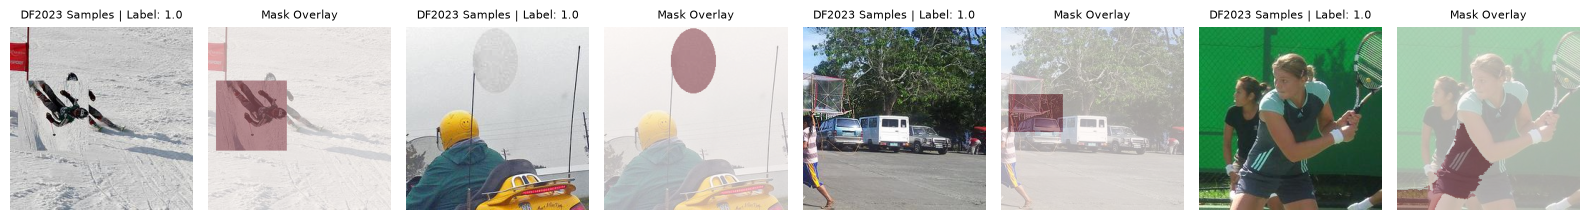

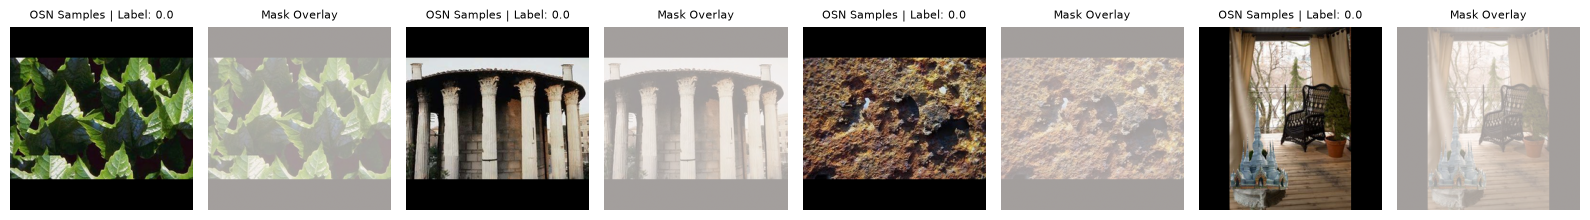

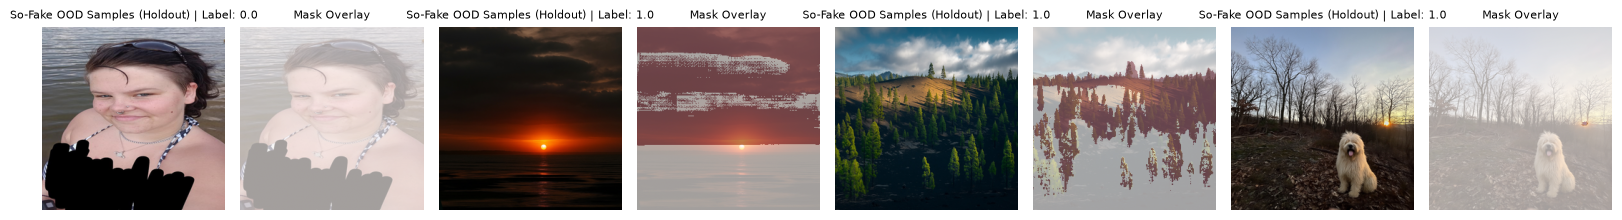


[Model] Initializing FakeShield‑T...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 187MB/s]


NameError: name 'SRM_INIT' is not defined

In [1]:
"""
FakeShield‑T — Complete Pipeline (Self‑Contained)
==================================================
All configuration, dataset loading, model architecture,
training loop, and visualizations in one cell.
"""

import os
import math
import random
import io
import warnings
from pathlib import Path
from typing import Optional, List, Dict
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ================================================================
# 1. CONFIGURATION (all hyper‑parameters)
# ================================================================

# ---------- Kaggle Input Paths ----------
KAGGLE_INPUT = Path("/kaggle/input/datasets/mubarekahmed")
DF2023_ROOT   = KAGGLE_INPUT / "df2023-subset" / "DF2023_V15_val"
OSN_ROOT      = KAGGLE_INPUT / "imageforensicsosn1" / "osn_dataset" / "ImageForgeriesOSN_Dataset"
SOFAKE_ROOT   = KAGGLE_INPUT / "so-fake-setted" / "so_fake_combined"
TRUEFAKE_ROOT = KAGGLE_INPUT / "trurfake" / "truefake_full"

# ---------- Local cache directories ----------
BASE_DIR      = Path.cwd()
PROCESSED_DIR = BASE_DIR / "processed"
CKPT_DIR      = BASE_DIR / "checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

# ---------- Image settings ----------
IMG_SIZE = 256
MEAN     = [0.485, 0.456, 0.406]
STD      = [0.229, 0.224, 0.225]

# ---------- Dataset budget ----------
TOTAL_BUDGET    = 20_000
TRAIN_FRAC      = 0.70
VAL_FRAC        = 0.15
TEST_FRAC       = 0.15
SOURCE_BUDGET = {
    "osn":           5_000,
    "df2023":        8_000,
    "truefake_gan":  2_000,
    "truefake_diff": 2_000,
    "sofake_ood":    3_000,
}
assert sum(SOURCE_BUDGET.values()) == TOTAL_BUDGET
AUTHENTIC_RATIO = 0.50

# ---------- OSN platforms ----------
TRAIN_PLATFORMS = ["", "Facebook", "Whatsapp"]

# ---------- Platform augmentation ----------
PLATFORM_AUG = {
    "telegram":  {"jpeg_quality": (60, 75), "resize_factor": (0.8, 1.0), "stages": 2, "chroma": False},
    "whatsapp":  {"jpeg_quality": (70, 80), "resize_factor": (0.7, 0.9), "stages": 1, "chroma": False},
    "facebook":  {"jpeg_quality": (75, 85), "resize_factor": (0.8, 1.0), "stages": 1, "chroma": False},
}
AUG_PROB = 0.5

# ---------- Model architecture ----------
FPN_CHANNELS        = 128
PANET_CHANNELS      = 128
FUSION_DIM          = FPN_CHANNELS   # must match
FUSION_HEADS        = 4
FUSION_DROPOUT      = 0.1
METADATA_INPUT_DIM  = 32
METADATA_EMBED_DIM  = 128
SEG_OUT_CHANNELS    = 1
CLS_HIDDEN_DIM      = 256
CLS_DROPOUT         = 0.3
CLS_LOSS_WEIGHT     = 0.4
SEG_LOSS_WEIGHT     = 0.6
BCE_POS_WEIGHT      = 2.0

# ---------- Training ----------
BATCH_SIZE = 16
NUM_EPOCHS = 30
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================================================================
# 2. PREPROCESSING FUNCTIONS (SRM‑aware)
# ================================================================

def _lanczos_pad(img: Image.Image, size: int) -> Image.Image:
    w, h = img.size
    scale = size / max(w, h)
    nw, nh = int(w * scale), int(h * scale)
    img = img.resize((nw, nh), Image.LANCZOS)
    canvas = Image.new("RGB", (size, size), 0)
    canvas.paste(img, ((size - nw) // 2, (size - nh) // 2))
    return canvas

def _simulate_platform(img: Image.Image, platform: str) -> Image.Image:
    if random.random() > AUG_PROB:
        return img
    cfg = PLATFORM_AUG.get(platform, PLATFORM_AUG["whatsapp"])
    subsampling = 2 if cfg["chroma"] else 0
    for _ in range(cfg["stages"]):
        q = random.randint(*cfg["jpeg_quality"])
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=q, subsampling=subsampling)
        buf.seek(0)
        img = Image.open(buf).copy()
    rf = random.uniform(*cfg["resize_factor"])
    nw = max(32, int(img.width * rf))
    nh = max(32, int(img.height * rf))
    img = img.resize((nw, nh), Image.BILINEAR)
    return img

def build_transforms(train: bool = True):
    ops = [T.Lambda(lambda img: _lanczos_pad(img, IMG_SIZE))]
    if train:
        ops += [
            T.RandomHorizontalFlip(0.5),
            T.RandomVerticalFlip(0.1),
            T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
        ]
    ops += [T.ToTensor(), T.Normalize(MEAN, STD)]
    return T.Compose(ops)

def build_mask_transform():
    return T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.NEAREST),
        T.ToTensor(),
    ])

# ================================================================
# 3. DATA STRUCTURES & DATASET CLASS
# ================================================================

class ForgeryItem:
    __slots__ = ("img_path", "mask_path", "label", "source", "platform")
    def __init__(self, img_path, mask_path, label, source, platform="original"):
        self.img_path  = str(img_path)
        self.mask_path = str(mask_path) if mask_path else None
        self.label     = int(label)
        self.source    = source
        self.platform  = platform

class ForgeryDataset(Dataset):
    def __init__(self, items, train=True, platform_aug=None):
        self.items = items
        self.train = train
        self.platform_aug = platform_aug
        self.img_tf  = build_transforms(train)
        self.mask_tf = build_mask_transform()

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        img = Image.open(item.img_path).convert("RGB")
        if self.train and self.platform_aug:
            img = _simulate_platform(img, self.platform_aug)
        img_t = self.img_tf(img)

        if item.mask_path and os.path.exists(item.mask_path):
            mask = Image.open(item.mask_path).convert("L")
            mask_t = self.mask_tf(mask)
            mask_t = (mask_t > 0.5).float()
        else:
            mask_t = torch.zeros(1, IMG_SIZE, IMG_SIZE)

        meta = {"available": False, "vector": torch.zeros(32)}
        return img_t, mask_t, torch.tensor(item.label, dtype=torch.float32), meta

# ================================================================
# 4. DATASET LOADERS (OSN, DF2023, TrueFake, So‑Fake OOD)
# ================================================================

def _osn_items(base_name: str, budget: int) -> List[ForgeryItem]:
    items = []
    base_dir = Path(OSN_ROOT) / base_name
    gt_dir   = Path(OSN_ROOT) / f"{base_name}_GT"
    if not base_dir.exists():
        return items

    all_imgs = list(base_dir.glob("*.jpg")) + list(base_dir.glob("*.png"))
    for plat in TRAIN_PLATFORMS:
        if plat:
            plat_dir = Path(OSN_ROOT) / f"{base_name}_{plat}"
            if plat_dir.exists():
                all_imgs += list(plat_dir.glob("*.jpg")) + list(plat_dir.glob("*.png"))

    forged_pool = []
    for f in all_imgs:
        masks = list(gt_dir.glob(f.stem + ".*"))
        if masks:
            forged_pool.append((f, masks[0]))

    n_forged = int(budget * AUTHENTIC_RATIO)
    n_forged = min(n_forged, len(forged_pool))
    if n_forged > 0:
        selected = random.sample(forged_pool, n_forged)
        for img_path, mask_path in selected:
            parent = img_path.parent.name
            platform = parent if parent != base_name else "original"
            items.append(ForgeryItem(img_path, mask_path, label=1,
                                     source=f"osn_{base_name.lower()}", platform=platform))

    auth_pool = [f for f in (list(base_dir.glob("*.jpg")) + list(base_dir.glob("*.png")))
                 if not any(gt_dir.glob(f.stem + ".*"))]
    n_auth = budget - n_forged
    n_auth = min(n_auth, len(auth_pool))
    if n_auth > 0:
        for f in random.sample(auth_pool, n_auth):
            items.append(ForgeryItem(f, None, label=0,
                                     source=f"osn_{base_name.lower()}", platform="original"))
    random.shuffle(items)
    return items[:budget]

def _df2023_items(budget: int) -> List[ForgeryItem]:
    items = []
    img_dir  = Path(DF2023_ROOT) / "COCO_V15"
    mask_dir = Path(DF2023_ROOT) / "COCO_V15_GT"
    if not img_dir.exists():
        return items

    all_imgs = sorted(img_dir.glob("*.jpg"))
    from collections import defaultdict
    by_comp = defaultdict(list)
    for f in all_imgs:
        parts = f.stem.split("_")
        comp = parts[2] if len(parts) > 2 else "C100"
        by_comp[comp].append(f)

    n_comp = len(by_comp) or 1
    per_c = max(1, (budget // 2) // n_comp)
    forged = []
    for files in by_comp.values():
        forged.extend(random.sample(files, min(per_c, len(files))))
    forged = forged[:budget // 2]
    for f in forged:
        mask = mask_dir / (f.stem + "_GT.png")
        if mask.exists():
            items.append(ForgeryItem(f, mask, label=1, source="df2023"))

    auth_pool = [f for f in all_imgs if not (mask_dir / (f.stem + "_GT.png")).exists()]
    n_auth = budget - len(items)
    if n_auth > 0 and auth_pool:
        auth_sample = random.sample(auth_pool, min(n_auth, len(auth_pool)))
        for f in auth_sample:
            items.append(ForgeryItem(f, None, label=0, source="df2023"))
    random.shuffle(items)
    return items[:budget]

def _truefake_items(gan_budget: int, diff_budget: int) -> List[ForgeryItem]:
    items = []
    root = Path(TRUEFAKE_ROOT)
    if not root.exists():
        return items

    gan_dir = root / "Facebook" / "Fake"
    if gan_dir.exists():
        gan_files = list(gan_dir.glob("*.jpg")) + list(gan_dir.glob("*.png"))
        if gan_files:
            gan_files = random.sample(gan_files, min(gan_budget // 2, len(gan_files)))
            for f in gan_files:
                items.append(ForgeryItem(f, None, label=1, source="truefake_gan", platform="original"))

    diff_dir = root / "Telegram" / "Fake"
    if diff_dir.exists():
        diff_files = list(diff_dir.glob("*.jpg")) + list(diff_dir.glob("*.png"))
        if diff_files:
            diff_files = random.sample(diff_files, min(diff_budget // 2, len(diff_files)))
            for f in diff_files:
                items.append(ForgeryItem(f, None, label=1, source="truefake_diff", platform="original"))

    total_fake = gan_budget + diff_budget
    n_auth = total_fake // 2
    real_pool = []
    for rd in [root / "Facebook" / "Real", root / "Telegram" / "Real"]:
        if rd.exists():
            real_pool += list(rd.glob("*.jpg")) + list(rd.glob("*.png"))
    if real_pool and n_auth > 0:
        real_sample = random.sample(real_pool, min(n_auth, len(real_pool)))
        for f in real_sample:
            items.append(ForgeryItem(f, None, label=0, source="truefake_real", platform="original"))
    random.shuffle(items)
    return items[:gan_budget + diff_budget]

def _sofake_ood_items(budget: int) -> List[ForgeryItem]:
    items = []
    try:
        import pandas as pd
    except ImportError:
        return items
    ood_dir = Path(SOFAKE_ROOT) / "ood_test"
    cache_dir = Path(PROCESSED_DIR) / "sofake_ood_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    if not ood_dir.exists():
        return items

    needed = budget
    for pq in sorted(ood_dir.glob("*.parquet")):
        if needed <= 0:
            break
        df = pd.read_parquet(pq)
        for _, row in df.iterrows():
            if needed <= 0:
                break
            img_col = next((c for c in ("image", "img", "image_bytes") if c in row.index), None)
            if img_col is None:
                continue
            try:
                img_bytes = row[img_col]
                if isinstance(img_bytes, dict):
                    img_bytes = img_bytes.get("bytes", b"")
                img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
                fname = f"ood_{len(items):06d}"
                img_path = cache_dir / f"{fname}.jpg"
                img.save(img_path, "JPEG", quality=95)
                mask_col = next((c for c in ("mask", "gt_mask", "gt") if c in row.index), None)
                mask_path = None
                if mask_col is not None:
                    try:
                        mb = row[mask_col]
                        if isinstance(mb, dict):
                            mb = mb.get("bytes", b"")
                        mask = Image.open(io.BytesIO(mb)).convert("L")
                        mask_path = cache_dir / f"{fname}_mask.png"
                        mask.save(mask_path)
                    except Exception:
                        pass
                label = int(row.get("label", 1))
                items.append(ForgeryItem(img_path, mask_path, label=label,
                                         source="sofake_ood", platform="ood"))
                needed -= 1
            except Exception:
                continue
    return items

def build_all_items() -> Dict[str, List[ForgeryItem]]:
    print("="*60)
    print("FakeShield-T  |  Dataset Assembly  |  Budget = 20,000")
    print("="*60)

    all_items = []
    for base in ["CASIA", "Columbia", "DSO", "NIST16"]:
        per_base = SOURCE_BUDGET["osn"] // 4
        items = _osn_items(base, per_base)
        print(f"  OSN {base:<12}: {len(items):>5} items")
        all_items.extend(items)

    df2023 = _df2023_items(SOURCE_BUDGET["df2023"])
    print(f"  DF2023       : {len(df2023):>5} items")
    all_items.extend(df2023)

    truefake = _truefake_items(SOURCE_BUDGET["truefake_gan"], SOURCE_BUDGET["truefake_diff"])
    print(f"  TrueFake     : {len(truefake):>5} items")
    all_items.extend(truefake)

    ood_items = _sofake_ood_items(SOURCE_BUDGET["sofake_ood"])
    print(f"  So-Fake OOD  : {len(ood_items):>5} items (held-out)")

    random.shuffle(all_items)
    n = len(all_items)
    n_tr = int(n * TRAIN_FRAC)
    n_val = int(n * VAL_FRAC)
    train_items = all_items[:n_tr]
    val_items   = all_items[n_tr:n_tr+n_val]
    test_items  = all_items[n_tr+n_val:]

    print("-"*60)
    print(f"  Train  : {len(train_items):>5}")
    print(f"  Val    : {len(val_items):>5}")
    print(f"  Test   : {len(test_items):>5}")
    print(f"  OOD    : {len(ood_items):>5}")
    print("="*60)

    return {"train": train_items, "val": val_items, "test": test_items, "ood": ood_items}

def build_dataloaders(batch_size: int = BATCH_SIZE, num_workers: int = 2):
    splits = build_all_items()
    loaders = {}
    for split, items in splits.items():
        is_train = (split == "train")
        aug_platform = random.choice(list(PLATFORM_AUG.keys())) if is_train else None
        ds = ForgeryDataset(items, train=is_train, platform_aug=aug_platform)
        loaders[split] = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=is_train,
            num_workers=num_workers,
            pin_memory=torch.cuda.is_available(),
            drop_last=is_train,
        )
    return loaders

# ================================================================
# 5. VISUALIZATION FUNCTIONS
# ================================================================

def show_samples(dataset, title="Samples", num_samples=4, cols=4, save_path=None):
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols * 2, figsize=(cols * 4, rows * 3))
    if rows == 1:
        axes = axes.reshape(1, -1)
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
    for i, idx in enumerate(indices):
        row = i // cols
        col = (i % cols) * 2
        item = dataset[idx]
        img = item[0].permute(1,2,0).cpu().numpy()
        mask = item[1].squeeze().cpu().numpy()
        label = item[2].item()
        # Unnormalize
        img = img * np.array(STD).reshape(1,1,3) + np.array(MEAN).reshape(1,1,3)
        img = np.clip(img, 0, 1)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{title} | Label: {label}", fontsize=8)
        axes[row, col].axis('off')
        axes[row, col+1].imshow(img, alpha=0.6)
        axes[row, col+1].imshow(mask, cmap='Reds', alpha=0.4, vmin=0, vmax=1)
        axes[row, col+1].set_title("Mask Overlay", fontsize=8)
        axes[row, col+1].axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100)
    plt.show()

def show_predictions(model, dataloader, device, num_samples=4, title="Predictions"):
    model.eval()
    images, masks, labels, meta = next(iter(dataloader))
    images = images[:num_samples].to(device)
    masks = masks[:num_samples].to(device)
    with torch.no_grad():
        cls_logit, mask_logit = model(images, meta)
        cls_proba = torch.sigmoid(cls_logit).cpu().numpy()
        mask_proba = torch.sigmoid(mask_logit).cpu().numpy()

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    for i in range(num_samples):
        img = images[i].cpu().permute(1,2,0).numpy()
        img = img * np.array(STD).reshape(1,1,3) + np.array(MEAN).reshape(1,1,3)
        img = np.clip(img, 0, 1)
        gt_mask = masks[i].cpu().squeeze().numpy()
        pred_mask = mask_proba[i].squeeze()
        # Image
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Image | True: {int(labels[i])}", fontsize=10)
        axes[i, 0].axis('off')
        # Ground truth mask
        axes[i, 1].imshow(img, alpha=0.6)
        axes[i, 1].imshow(gt_mask, cmap='Reds', alpha=0.4, vmin=0, vmax=1)
        axes[i, 1].set_title(f"GT Mask | IoU: ---", fontsize=10)
        axes[i, 1].axis('off')
        # Predicted mask
        axes[i, 2].imshow(img, alpha=0.6)
        axes[i, 2].imshow(pred_mask, cmap='Blues', alpha=0.4, vmin=0, vmax=1)
        axes[i, 2].set_title(f"Pred Mask | Score: {cls_proba[i]:.3f}", fontsize=10)
        axes[i, 2].axis('off')
    plt.tight_layout()
    plt.suptitle(title, fontsize=14)
    plt.show()

# ================================================================
# 6. MODEL DEFINITION (FakeShield‑T)
# ================================================================

def _build_srm_kernels() -> torch.Tensor:
    srm = np.zeros((30, 1, 5, 5), dtype=np.float32)
    srm[0, 0] = [[0,0,0,0,0],[0,0,1,0,0],[0,0,-1,0,0],[0,0,0,0,0],[0,0,0,0,0]]
    srm[1, 0] = [[0,0,0,0,0],[0,0,1,-1,0],[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0]]
    srm[2, 0] = [[0,0,0,0,0],[0,0,-1,0,0],[0,0,2,-1,0],[0,0,0,0,0],[0,0,0,0,0]]
    srm[3, 0] = [[0,0,0,0,0],[0,-1,2,-1,0],[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0]]
    srm[4, 0] = [[0,0,0,0,0],[0,0,-1,0,0],[0,-1,4,-1,0],[0,0,-1,0,0],[0,0,0,0,0]]
    angles = np.linspace(0, 2*math.pi, 25, endpoint=False)
    cx, cy = 2, 2
    for i, a in enumerate(angles):
        k = np.zeros((5,5), dtype=np.float32)
        dx, dy = round(math.cos(a)), round(math.sin(a))
        x, y = cx + dx, cy + dy
        if 0 <= x < 5 and 0 <= y < 5:
            k[cy, cx] = 1.0
            k[y, x]   = -1.0
        srm[5+i, 0] = k / (np.abs(k).sum() + 1e-6)
    return torch.from_numpy(srm)

class DSConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel, stride, padding, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))

class ArtifactStream(nn.Module):
    def __init__(self):
        super().__init__()
        from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1
        backbone = efficientnet_b0(weights=weights)

        if SRM_INIT:
            first_conv = backbone.features[0][0]
            out_ch = first_conv.out_channels
            target_k = first_conv.weight.shape[2]
            srm = _build_srm_kernels()
            srm_rgb = srm.repeat(1, 3, 1, 1)
            if target_k != 5:
                pad = (5 - target_k) // 2
                srm_rgb = srm_rgb[:, :, pad:pad+target_k, pad:pad+target_k]
            if out_ch > srm_rgb.shape[0]:
                pad_n = out_ch - srm_rgb.shape[0]
                pad = torch.randn(pad_n, 3, target_k, target_k) * 0.01
                srm_rgb = torch.cat([srm_rgb, pad], dim=0)
            else:
                srm_rgb = srm_rgb[:out_ch]
            with torch.no_grad():
                first_conv.weight.copy_(srm_rgb)

        self.conv0 = backbone.features[0]
        self.conv1 = backbone.features[1]
        self.stage2 = nn.Sequential(*backbone.features[2:4])
        self.stage3 = nn.Sequential(*backbone.features[4:6])
        self.stage4 = nn.Sequential(*backbone.features[6:8])
        self.proj2 = nn.Conv2d(40, FPN_CHANNELS, 1)
        self.proj3 = nn.Conv2d(112, FPN_CHANNELS, 1)
        self.proj4 = nn.Conv2d(320, FPN_CHANNELS, 1)

    def forward(self, x):
        x = self.conv0(x)
        x = self.conv1(x)
        s2 = self.stage2(x)
        s3 = self.stage3(s2)
        s4 = self.stage4(s3)
        return self.proj2(s2), self.proj3(s3), self.proj4(s4)

class SemanticStream(nn.Module):
    def __init__(self, embed_dim=FUSION_DIM):
        super().__init__()
        try:
            import timm
            self.backbone = timm.create_model("tiny_vit_5m_224", pretrained=True, features_only=True, out_indices=(1,2,3))
            sample = torch.zeros(1,3,224,224)
            with torch.no_grad():
                outs = self.backbone(sample)
            self.out_chs = [o.shape[1] for o in outs]
            self.projs = nn.ModuleList([nn.Conv2d(c, embed_dim, 1) for c in self.out_chs])
            self._use_timm = True
        except:
            self._use_timm = False
            self.backbone = _FallbackViT(embed_dim=embed_dim)
            self.projs = nn.Identity()
    def forward(self, x):
        if self._use_timm:
            x224 = F.interpolate(x, size=224, mode="bilinear", align_corners=False)
            feats = self.backbone(x224)
            return [proj(f) for proj, f in zip(self.projs, feats)]
        else:
            return self.backbone(x)

class _FallbackViT(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.stage1 = nn.Sequential(nn.Conv2d(3,64,3,2,1), nn.GELU(), nn.BatchNorm2d(64),
                                    nn.Conv2d(64,64,3,1,1), nn.GELU(), nn.BatchNorm2d(64))
        self.stage2 = nn.Sequential(nn.Conv2d(64,128,3,2,1), nn.GELU(), nn.BatchNorm2d(128),
                                    nn.Conv2d(128,128,3,1,1), nn.GELU(), nn.BatchNorm2d(128))
        self.stage3 = nn.Sequential(nn.Conv2d(128,embed_dim,3,2,1), nn.GELU(), nn.BatchNorm2d(embed_dim),
                                    nn.Conv2d(embed_dim,embed_dim,3,1,1), nn.GELU(), nn.BatchNorm2d(embed_dim))
        self.proj1 = nn.Conv2d(64, embed_dim, 1)
        self.proj2 = nn.Conv2d(128, embed_dim, 1)
        self.proj3 = nn.Identity()
    def forward(self, x):
        s1 = self.stage1(x)
        s2 = self.stage2(s1)
        s3 = self.stage3(s2)
        return [self.proj1(s1), self.proj2(s2), self.proj3(s3)]

class MetadataEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(METADATA_INPUT_DIM, 64), nn.ReLU(),
                                 nn.Linear(64, METADATA_EMBED_DIM))
        self.missing_token = nn.Parameter(torch.randn(METADATA_EMBED_DIM))
        self.flag_embed = nn.Embedding(2, METADATA_EMBED_DIM)
    def forward(self, meta_dict):
        available = meta_dict.get("available", False)
        vec = meta_dict.get("vector")
        if vec is None or not available:
            B = 1 if vec is None else vec.shape[0]
            dev = self.missing_token.device
            token = self.missing_token.unsqueeze(0).expand(B, -1)
            flag = self.flag_embed(torch.zeros(B, dtype=torch.long, device=dev))
            return token + flag
        else:
            if not isinstance(vec, torch.Tensor):
                vec = torch.tensor(vec, dtype=torch.float32)
            vec = vec.to(self.missing_token.device)
            emb = self.mlp(vec)
            flag = self.flag_embed(torch.ones(vec.shape[0], dtype=torch.long, device=vec.device))
            return emb + flag

class ModalityAwareCrossAttention(nn.Module):
    def __init__(self, dim=FUSION_DIM):
        super().__init__()
        self.q_proj = nn.Linear(METADATA_EMBED_DIM, dim)
        self.attn = nn.MultiheadAttention(dim, FUSION_HEADS, dropout=FUSION_DROPOUT, batch_first=True)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(nn.Linear(dim, dim*2), nn.GELU(), nn.Linear(dim*2, dim))
        self.gate = nn.Parameter(torch.ones(1))
    def forward(self, artifact_feat, semantic_feat, meta_emb):
        B, C, H, W = artifact_feat.shape
        A = artifact_feat.flatten(2).transpose(1,2)
        S = semantic_feat.flatten(2).transpose(1,2)
        V = torch.cat([A, S], dim=1)
        Q = self.q_proj(meta_emb).unsqueeze(1)
        attn_out, _ = self.attn(Q, V, V)
        gated = self.gate * attn_out + Q
        gated = self.norm1(gated)
        gated = self.norm2(gated + self.ff(gated))
        ctx = gated.transpose(1,2).unsqueeze(-1)
        fused = (artifact_feat + semantic_feat) * torch.sigmoid(ctx)
        return fused

class SegmentationHead(nn.Module):
    def __init__(self, in_channels=FPN_CHANNELS):
        super().__init__()
        C = PANET_CHANNELS
        self.lat3 = nn.Conv2d(in_channels, C, 1)
        self.lat2 = nn.Conv2d(in_channels, C, 1)
        self.lat1 = nn.Conv2d(in_channels, C, 1)
        self.td3 = DSConv(C, C)
        self.td2 = DSConv(C, C)
        self.td1 = DSConv(C, C)
        self.bu2 = DSConv(C, C, stride=2)
        self.bu3 = DSConv(C, C, stride=2)
        self.merge2 = DSConv(C*2, C)
        self.merge3 = DSConv(C*2, C)
        self.upsample = nn.Sequential(
            DSConv(C, C),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            DSConv(C, C//2),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            DSConv(C//2, C//4),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(C//4, SEG_OUT_CHANNELS, 1),
        )
    def forward(self, feats):
        p1, p2, p3 = feats
        l3 = self.lat3(p3)
        l2 = self.lat2(p2) + F.interpolate(l3, scale_factor=2, mode="nearest")
        l1 = self.lat1(p1) + F.interpolate(l2, scale_factor=2, mode="nearest")
        t3 = self.td3(l3)
        t2 = self.td2(l2)
        t1 = self.td1(l1)
        b2 = self.merge2(torch.cat([t2, self.bu2(t1)], 1))
        b3 = self.merge3(torch.cat([t3, self.bu3(b2)], 1))
        mask_logit = self.upsample(t1 + F.interpolate(b2, size=t1.shape[2:], mode="bilinear", align_corners=False))
        return mask_logit

class ClassificationHead(nn.Module):
    def __init__(self, in_ch=FPN_CHANNELS):
        super().__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(nn.Flatten(),
                                 nn.Linear(in_ch, CLS_HIDDEN_DIM), nn.GELU(),
                                 nn.Dropout(CLS_DROPOUT),
                                 nn.Linear(CLS_HIDDEN_DIM, 1))
    def forward(self, x):
        return self.mlp(self.gap(x)).squeeze(-1)

class FakeShieldT(nn.Module):
    def __init__(self):
        super().__init__()
        self.artifact_stream = ArtifactStream()
        self.semantic_stream = SemanticStream(embed_dim=FUSION_DIM)
        self.meta_encoder = MetadataEncoder()
        self.fusion = ModalityAwareCrossAttention(dim=FUSION_DIM)
        self.seg_head = SegmentationHead(in_channels=FPN_CHANNELS)
        self.cls_head = ClassificationHead(in_ch=FUSION_DIM)
    def forward(self, img, meta):
        a2, a3, a4 = self.artifact_stream(img)
        sem_feats = self.semantic_stream(img)
        s2 = F.interpolate(sem_feats[0], size=a2.shape[2:], mode="bilinear", align_corners=False)
        s3 = F.interpolate(sem_feats[1], size=a3.shape[2:], mode="bilinear", align_corners=False)
        s4 = F.interpolate(sem_feats[2], size=a4.shape[2:], mode="bilinear", align_corners=False)
        meta_emb = self.meta_encoder(meta)
        f2 = self.fusion(a2, s2, meta_emb)
        f3 = self.fusion(a3, s3, meta_emb)
        f4 = self.fusion(a4, s4, meta_emb)
        mask_logit = self.seg_head([f2, f3, f4])
        cls_logit = self.cls_head(f3)
        return cls_logit, mask_logit
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

class FakeShieldLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.w_cls = CLS_LOSS_WEIGHT
        self.w_seg = SEG_LOSS_WEIGHT
        self.bce_cls = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(BCE_POS_WEIGHT))
        self.bce_seg = nn.BCEWithLogitsLoss()
    def dice_loss(self, pred, target, eps=1e-6):
        pred = torch.sigmoid(pred)
        inter = (pred * target).sum(dim=(1,2,3))
        denom = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
        return 1 - (2*inter + eps) / (denom + eps)
    def forward(self, cls_logit, mask_logit, label, mask_gt):
        self.bce_cls.pos_weight = self.bce_cls.pos_weight.to(cls_logit.device)
        loss_cls = self.bce_cls(cls_logit, label)
        loss_seg = self.bce_seg(mask_logit, mask_gt) + self.dice_loss(mask_logit, mask_gt).mean()
        return self.w_cls * loss_cls + self.w_seg * loss_seg, {"cls": loss_cls.item(), "seg": loss_seg.item()}

# ================================================================
# 7. METRIC COMPUTATION
# ================================================================

def compute_cls_metrics(labels, preds_proba, thresh=0.5):
    preds_bin = (preds_proba >= thresh).astype(int)
    acc = accuracy_score(labels, preds_bin)
    prec = precision_score(labels, preds_bin, zero_division=0)
    rec = recall_score(labels, preds_bin, zero_division=0)
    f1 = f1_score(labels, preds_bin, zero_division=0)
    auc = roc_auc_score(labels, preds_proba) if len(np.unique(labels))>1 else 0.0
    return {"accuracy":acc, "precision":prec, "recall":rec, "f1":f1, "auc":auc}

def compute_seg_metrics(pred_masks, gt_masks, thresh=0.5):
    pred_bin = (pred_masks >= thresh).astype(int)
    gt_bin = (gt_masks >= 0.5).astype(int)
    pred_flat = pred_bin.flatten()
    gt_flat = gt_bin.flatten()
    pixel_acc = np.mean(pred_flat == gt_flat)
    inter = np.sum(pred_flat * gt_flat)
    union = np.sum(pred_flat) + np.sum(gt_flat) - inter
    iou = inter / (union + 1e-6)
    dice = (2*inter) / (np.sum(pred_flat) + np.sum(gt_flat) + 1e-6)
    return {"pixel_accuracy":pixel_acc, "iou":iou, "dice":dice}

def evaluate(model, dataloader, loss_fn, device, desc="Evaluating"):
    model.eval()
    total_loss = 0.0
    all_labels, all_preds, all_masks, all_gt = [], [], [], []
    with torch.no_grad():
        for images, masks, labels, meta in tqdm(dataloader, desc=desc, leave=False):
            images = images.to(device); masks = masks.to(device); labels = labels.to(device)
            cls_logit, mask_logit = model(images, meta)
            loss, _ = loss_fn(cls_logit, mask_logit, labels, masks)
            total_loss += loss.item()
            cls_proba = torch.sigmoid(cls_logit).cpu().numpy()
            mask_proba = torch.sigmoid(mask_logit).cpu().numpy()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(cls_proba)
            all_masks.extend(mask_proba)
            all_gt.extend(masks.cpu().numpy())
    labels_np = np.array(all_labels)
    preds_np = np.array(all_preds)
    masks_np = np.array(all_masks)
    gt_np = np.array(all_gt)
    cls_met = compute_cls_metrics(labels_np, preds_np)
    seg_met = compute_seg_metrics(masks_np, gt_np)
    return {"loss": total_loss/len(dataloader), **cls_met, **seg_met}

# ================================================================
# 8. MAIN PIPELINE
# ================================================================

def main():
    print("="*60)
    print("FakeShield‑T  |  Full Pipeline")
    print(f"Device: {DEVICE}")
    print("="*60)

    # ---------- Build data loaders ----------
    loaders = build_dataloaders(batch_size=BATCH_SIZE)
    train_loader = loaders["train"]
    val_loader = loaders["val"]
    test_loader = loaders["test"]
    ood_loader = loaders["ood"]

    # ---------- Visualize samples from each source ----------
    print("\n[Visualization] Displaying sample images with masks from each source...")
    # We'll take a subset from each loader's dataset
    # For train_loader, we can access its dataset directly
    train_ds = train_loader.dataset
    val_ds = val_loader.dataset
    test_ds = test_loader.dataset
    ood_ds = ood_loader.dataset

    # Show samples from DF2023 (we need to extract those items)
    # Since the dataset is a ForgeryDataset wrapping items, we can get items from its .items attribute
    df2023_items = [it for it in train_ds.items if it.source == "df2023"]
    if df2023_items:
        df2023_ds = ForgeryDataset(df2023_items[:20], train=False)
        show_samples(df2023_ds, title="DF2023 Samples", num_samples=4)
    else:
        print("No DF2023 items found in training set.")

    # OSN samples
    osn_items = [it for it in train_ds.items if it.source.startswith("osn_")]
    if osn_items:
        osn_ds = ForgeryDataset(osn_items[:20], train=False)
        show_samples(osn_ds, title="OSN Samples", num_samples=4)

    # TrueFake samples
    tf_items = [it for it in train_ds.items if it.source.startswith("truefake")]
    if tf_items:
        tf_ds = ForgeryDataset(tf_items[:20], train=False)
        show_samples(tf_ds, title="TrueFake Samples (GAN/Diffusion)", num_samples=4)

    # OOD samples
    if len(ood_ds) > 0:
        show_samples(ood_ds, title="So-Fake OOD Samples (Holdout)", num_samples=4)

    # ---------- Initialize model ----------
    print("\n[Model] Initializing FakeShield‑T...")
    model = FakeShieldT().to(DEVICE)
    loss_fn = FakeShieldLoss().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    print(f"Total parameters: {model.count_parameters():,}")

    # ---------- Training loop ----------
    print(f"\n[Training] Starting for {NUM_EPOCHS} epochs...")
    best_val_loss = float('inf')
    best_state = None
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_iou": []}

    for epoch in range(1, NUM_EPOCHS + 1):
        print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
        print("-" * 40)

        # Train
        model.train()
        train_loss = 0.0
        pbar = tqdm(train_loader, desc="Training", leave=False)
        for images, masks, labels, meta in pbar:
            images = images.to(DEVICE); masks = masks.to(DEVICE); labels = labels.to(DEVICE)
            optimizer.zero_grad()
            cls_logit, mask_logit = model(images, meta)
            loss, _ = loss_fn(cls_logit, mask_logit, labels, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        avg_train_loss = train_loss / len(train_loader)
        history["train_loss"].append(avg_train_loss)

        # Validate
        val_metrics = evaluate(model, val_loader, loss_fn, DEVICE, desc="Validating")
        val_loss = val_metrics["loss"]
        val_acc = val_metrics["accuracy"]
        val_iou = val_metrics["iou"]
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_iou"].append(val_iou)

        scheduler.step()

        # Print summary
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Val Acc: {val_acc:.4f} | Prec: {val_metrics['precision']:.4f} "
              f"| Rec: {val_metrics['recall']:.4f} | F1: {val_metrics['f1']:.4f}")
        print(f"Val IoU: {val_iou:.4f} | Dice: {val_metrics['dice']:.4f}")

        # Save best
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, os.path.join(CKPT_DIR, "best_model.pth"))
            print(f"✅ New best model saved (val_loss = {val_loss:.4f})")

    # ---------- Load best model ----------
    if best_state is not None:
        model.load_state_dict(best_state)
    print("\n[Evaluation] Running on Test and OOD sets using best model...")

    # ---------- Test evaluation ----------
    test_metrics = evaluate(model, test_loader, loss_fn, DEVICE, desc="Testing (ID)")
    print("\n🔹 Test Set Results (In-Distribution):")
    print(f"  Loss:     {test_metrics['loss']:.4f}")
    print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"  Precision:{test_metrics['precision']:.4f}")
    print(f"  Recall:   {test_metrics['recall']:.4f}")
    print(f"  F1-Score: {test_metrics['f1']:.4f}")
    print(f"  AUC:      {test_metrics['auc']:.4f}")
    print(f"  Pixel Acc:{test_metrics['pixel_accuracy']:.4f}")
    print(f"  IoU:      {test_metrics['iou']:.4f}")
    print(f"  Dice:     {test_metrics['dice']:.4f}")

    # ---------- OOD evaluation ----------
    ood_metrics = evaluate(model, ood_loader, loss_fn, DEVICE, desc="OOD Testing")
    print("\n🔸 OOD Set Results (So-Fake-OOD):")
    print(f"  Loss:     {ood_metrics['loss']:.4f}")
    print(f"  Accuracy: {ood_metrics['accuracy']:.4f}")
    print(f"  Precision:{ood_metrics['precision']:.4f}")
    print(f"  Recall:   {ood_metrics['recall']:.4f}")
    print(f"  F1-Score: {ood_metrics['f1']:.4f}")
    print(f"  AUC:      {ood_metrics['auc']:.4f}")
    print(f"  Pixel Acc:{ood_metrics['pixel_accuracy']:.4f}")
    print(f"  IoU:      {ood_metrics['iou']:.4f}")
    print(f"  Dice:     {ood_metrics['dice']:.4f}")

    # ---------- Visualize predictions on test set ----------
    print("\n[Visualization] Showing sample predictions on test set...")
    show_predictions(model, test_loader, DEVICE, num_samples=4, title="Test Set Predictions")
    print("\n[Visualization] Showing sample predictions on OOD set...")
    if len(ood_loader) > 0:
        show_predictions(model, ood_loader, DEVICE, num_samples=4, title="OOD Set Predictions")

    print("\n" + "="*60)
    print("✅ Pipeline complete. Best model saved at:", os.path.join(CKPT_DIR, "best_model.pth"))
    return model, history, test_metrics, ood_metrics

# ================================================================
# RUN
# ================================================================
if __name__ == "__main__":
    model, history, test_met, ood_met = main()

In [ ]:
"""
FakeShield‑T — Complete Pipeline (Self‑Contained)
==================================================
All configuration, dataset loading, model architecture,
training loop, and visualizations in one cell.
"""

import os
import math
import random
import io
import copy
import warnings
from pathlib import Path
from typing import Optional, List, Dict
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ================================================================
# 1. CONFIGURATION (all hyper‑parameters)
# ================================================================

# ---------- Kaggle Input Paths ----------
KAGGLE_INPUT = Path("/kaggle/input/datasets/mubarekahmed")
DF2023_ROOT   = KAGGLE_INPUT / "df2023-subset" / "DF2023_V15_val"
OSN_ROOT      = KAGGLE_INPUT / "imageforensicsosn1" / "osn_dataset" / "ImageForgeriesOSN_Dataset"
SOFAKE_ROOT   = KAGGLE_INPUT / "so-fake-setted" / "so_fake_combined"
TRUEFAKE_ROOT = KAGGLE_INPUT / "trurfake" / "truefake_full"

# ---------- Local cache directories ----------
BASE_DIR      = Path.cwd()
PROCESSED_DIR = BASE_DIR / "processed"
CKPT_DIR      = BASE_DIR / "checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

# ---------- Image settings ----------
IMG_SIZE = 256
MEAN     = [0.485, 0.456, 0.406]
STD      = [0.229, 0.224, 0.225]

# ---------- Dataset budget ----------
TOTAL_BUDGET    = 8_000
TRAIN_FRAC      = 0.70
VAL_FRAC        = 0.15
TEST_FRAC       = 0.15
SOURCE_BUDGET = {
    "osn":           2_000,
    "df2023":        3_000,
    "truefake_gan":  1_000,
    "truefake_diff": 1_000,
    "sofake_ood":    1_000,
}
assert sum(SOURCE_BUDGET.values()) == TOTAL_BUDGET
AUTHENTIC_RATIO = 0.50

# ---------- OSN platforms ----------
TRAIN_PLATFORMS = ["", "Facebook", "Whatsapp"]

# ---------- Platform augmentation ----------
PLATFORM_AUG = {
    "telegram":  {"jpeg_quality": (60, 75), "resize_factor": (0.8, 1.0), "stages": 2, "chroma": False},
    "whatsapp":  {"jpeg_quality": (70, 80), "resize_factor": (0.7, 0.9), "stages": 1, "chroma": False},
    "facebook":  {"jpeg_quality": (75, 85), "resize_factor": (0.8, 1.0), "stages": 1, "chroma": False},
}
AUG_PROB = 0.5

# ---------- Model architecture ----------
SRM_INIT             = True   # initialize ArtifactStream's first conv with SRM noise-residual kernels
FPN_CHANNELS        = 128
PANET_CHANNELS      = 128
FUSION_DIM          = FPN_CHANNELS   # must match
FUSION_HEADS        = 4
FUSION_DROPOUT      = 0.1
METADATA_INPUT_DIM  = 32
METADATA_EMBED_DIM  = 128
SEG_OUT_CHANNELS    = 1
CLS_HIDDEN_DIM      = 256
CLS_DROPOUT         = 0.3
CLS_LOSS_WEIGHT     = 0.4
SEG_LOSS_WEIGHT     = 0.6
BCE_POS_WEIGHT      = 2.0

# ---------- Training ----------
BATCH_SIZE = 8
NUM_EPOCHS = 15
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================================================================
# 2. PREPROCESSING FUNCTIONS (SRM‑aware)
# ================================================================

def _lanczos_pad(img: Image.Image, size: int) -> Image.Image:
    w, h = img.size
    scale = size / max(w, h)
    nw, nh = int(w * scale), int(h * scale)
    img = img.resize((nw, nh), Image.LANCZOS)
    canvas = Image.new("RGB", (size, size), 0)
    canvas.paste(img, ((size - nw) // 2, (size - nh) // 2))
    return canvas

def _simulate_platform(img: Image.Image, platform: str) -> Image.Image:
    if random.random() > AUG_PROB:
        return img
    cfg = PLATFORM_AUG.get(platform, PLATFORM_AUG["whatsapp"])
    subsampling = 2 if cfg["chroma"] else 0
    for _ in range(cfg["stages"]):
        q = random.randint(*cfg["jpeg_quality"])
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=q, subsampling=subsampling)
        buf.seek(0)
        img = Image.open(buf).copy()
    rf = random.uniform(*cfg["resize_factor"])
    nw = max(32, int(img.width * rf))
    nh = max(32, int(img.height * rf))
    img = img.resize((nw, nh), Image.BILINEAR)
    return img

def build_transforms(train: bool = True):
    ops = [T.Lambda(lambda img: _lanczos_pad(img, IMG_SIZE))]
    if train:
        ops += [
            T.RandomHorizontalFlip(0.5),
            T.RandomVerticalFlip(0.1),
            T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
        ]
    ops += [T.ToTensor(), T.Normalize(MEAN, STD)]
    return T.Compose(ops)

def build_mask_transform():
    return T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.NEAREST),
        T.ToTensor(),
    ])

# ================================================================
# 3. DATA STRUCTURES & DATASET CLASS
# ================================================================

class ForgeryItem:
    __slots__ = ("img_path", "mask_path", "label", "source", "platform")
    def __init__(self, img_path, mask_path, label, source, platform="original"):
        self.img_path  = str(img_path)
        self.mask_path = str(mask_path) if mask_path else None
        self.label     = int(label)
        self.source    = source
        self.platform  = platform

class ForgeryDataset(Dataset):
    def __init__(self, items, train=True, platform_aug=None):
        self.items = items
        self.train = train
        self.platform_aug = platform_aug
        self.img_tf  = build_transforms(train)
        self.mask_tf = build_mask_transform()

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        img = Image.open(item.img_path).convert("RGB")
        if self.train and self.platform_aug:
            img = _simulate_platform(img, self.platform_aug)
        img_t = self.img_tf(img)

        if item.mask_path and os.path.exists(item.mask_path):
            mask = Image.open(item.mask_path).convert("L")
            mask_t = self.mask_tf(mask)
            mask_t = (mask_t > 0.5).float()
        else:
            mask_t = torch.zeros(1, IMG_SIZE, IMG_SIZE)

        meta = {"available": False, "vector": torch.zeros(32)}
        return img_t, mask_t, torch.tensor(item.label, dtype=torch.float32), meta

# ================================================================
# 4. DATASET LOADERS (OSN, DF2023, TrueFake, So‑Fake OOD)
# ================================================================

def _osn_items(base_name: str, budget: int) -> List[ForgeryItem]:
    items = []
    base_dir = Path(OSN_ROOT) / base_name
    gt_dir   = Path(OSN_ROOT) / f"{base_name}_GT"
    if not base_dir.exists():
        return items

    all_imgs = list(base_dir.glob("*.jpg")) + list(base_dir.glob("*.png"))
    for plat in TRAIN_PLATFORMS:
        if plat:
            plat_dir = Path(OSN_ROOT) / f"{base_name}_{plat}"
            if plat_dir.exists():
                all_imgs += list(plat_dir.glob("*.jpg")) + list(plat_dir.glob("*.png"))

    forged_pool = []
    for f in all_imgs:
        masks = list(gt_dir.glob(f.stem + ".*"))
        if masks:
            forged_pool.append((f, masks[0]))

    n_forged = int(budget * AUTHENTIC_RATIO)
    n_forged = min(n_forged, len(forged_pool))
    if n_forged > 0:
        selected = random.sample(forged_pool, n_forged)
        for img_path, mask_path in selected:
            parent = img_path.parent.name
            platform = parent if parent != base_name else "original"
            items.append(ForgeryItem(img_path, mask_path, label=1,
                                     source=f"osn_{base_name.lower()}", platform=platform))

    auth_pool = [f for f in (list(base_dir.glob("*.jpg")) + list(base_dir.glob("*.png")))
                 if not any(gt_dir.glob(f.stem + ".*"))]
    n_auth = budget - n_forged
    n_auth = min(n_auth, len(auth_pool))
    if n_auth > 0:
        for f in random.sample(auth_pool, n_auth):
            items.append(ForgeryItem(f, None, label=0,
                                     source=f"osn_{base_name.lower()}", platform="original"))
    random.shuffle(items)
    return items[:budget]

def _df2023_items(budget: int) -> List[ForgeryItem]:
    items = []
    img_dir  = Path(DF2023_ROOT) / "COCO_V15"
    mask_dir = Path(DF2023_ROOT) / "COCO_V15_GT"
    if not img_dir.exists():
        return items

    all_imgs = sorted(img_dir.glob("*.jpg"))
    from collections import defaultdict
    by_comp = defaultdict(list)
    for f in all_imgs:
        parts = f.stem.split("_")
        comp = parts[2] if len(parts) > 2 else "C100"
        by_comp[comp].append(f)

    n_comp = len(by_comp) or 1
    per_c = max(1, (budget // 2) // n_comp)
    forged = []
    for files in by_comp.values():
        forged.extend(random.sample(files, min(per_c, len(files))))
    forged = forged[:budget // 2]
    for f in forged:
        mask = mask_dir / (f.stem + "_GT.png")
        if mask.exists():
            items.append(ForgeryItem(f, mask, label=1, source="df2023"))

    auth_pool = [f for f in all_imgs if not (mask_dir / (f.stem + "_GT.png")).exists()]
    n_auth = budget - len(items)
    if n_auth > 0 and auth_pool:
        auth_sample = random.sample(auth_pool, min(n_auth, len(auth_pool)))
        for f in auth_sample:
            items.append(ForgeryItem(f, None, label=0, source="df2023"))
    random.shuffle(items)
    return items[:budget]

def _truefake_items(gan_budget: int, diff_budget: int) -> List[ForgeryItem]:
    items = []
    root = Path(TRUEFAKE_ROOT)
    if not root.exists():
        return items

    gan_dir = root / "Facebook" / "Fake"
    if gan_dir.exists():
        gan_files = list(gan_dir.glob("*.jpg")) + list(gan_dir.glob("*.png"))
        if gan_files:
            gan_files = random.sample(gan_files, min(gan_budget // 2, len(gan_files)))
            for f in gan_files:
                items.append(ForgeryItem(f, None, label=1, source="truefake_gan", platform="original"))

    diff_dir = root / "Telegram" / "Fake"
    if diff_dir.exists():
        diff_files = list(diff_dir.glob("*.jpg")) + list(diff_dir.glob("*.png"))
        if diff_files:
            diff_files = random.sample(diff_files, min(diff_budget // 2, len(diff_files)))
            for f in diff_files:
                items.append(ForgeryItem(f, None, label=1, source="truefake_diff", platform="original"))

    total_fake = gan_budget + diff_budget
    n_auth = total_fake // 2
    real_pool = []
    for rd in [root / "Facebook" / "Real", root / "Telegram" / "Real"]:
        if rd.exists():
            real_pool += list(rd.glob("*.jpg")) + list(rd.glob("*.png"))
    if real_pool and n_auth > 0:
        real_sample = random.sample(real_pool, min(n_auth, len(real_pool)))
        for f in real_sample:
            items.append(ForgeryItem(f, None, label=0, source="truefake_real", platform="original"))
    random.shuffle(items)
    return items[:gan_budget + diff_budget]

def _sofake_ood_items(budget: int) -> List[ForgeryItem]:
    items = []
    try:
        import pandas as pd
    except ImportError:
        return items
    ood_dir = Path(SOFAKE_ROOT) / "ood_test"
    cache_dir = Path(PROCESSED_DIR) / "sofake_ood_cache"
    cache_dir.mkdir(parents=True, exist_ok=True)
    if not ood_dir.exists():
        return items

    needed = budget
    for pq in sorted(ood_dir.glob("*.parquet")):
        if needed <= 0:
            break
        df = pd.read_parquet(pq)
        for _, row in df.iterrows():
            if needed <= 0:
                break
            img_col = next((c for c in ("image", "img", "image_bytes") if c in row.index), None)
            if img_col is None:
                continue
            try:
                img_bytes = row[img_col]
                if isinstance(img_bytes, dict):
                    img_bytes = img_bytes.get("bytes", b"")
                img = Image.open(io.BytesIO(img_bytes)).convert("RGB")
                fname = f"ood_{len(items):06d}"
                img_path = cache_dir / f"{fname}.jpg"
                img.save(img_path, "JPEG", quality=95)
                mask_col = next((c for c in ("mask", "gt_mask", "gt") if c in row.index), None)
                mask_path = None
                if mask_col is not None:
                    try:
                        mb = row[mask_col]
                        if isinstance(mb, dict):
                            mb = mb.get("bytes", b"")
                        mask = Image.open(io.BytesIO(mb)).convert("L")
                        mask_path = cache_dir / f"{fname}_mask.png"
                        mask.save(mask_path)
                    except Exception:
                        pass
                label = int(row.get("label", 1))
                items.append(ForgeryItem(img_path, mask_path, label=label,
                                         source="sofake_ood", platform="ood"))
                needed -= 1
            except Exception:
                continue
    return items

def build_all_items() -> Dict[str, List[ForgeryItem]]:
    print("="*60)
    print("FakeShield-T  |  Dataset Assembly  |  Budget = 20,000")
    print("="*60)

    all_items = []
    for base in ["CASIA", "Columbia", "DSO", "NIST16"]:
        per_base = SOURCE_BUDGET["osn"] // 4
        items = _osn_items(base, per_base)
        print(f"  OSN {base:<12}: {len(items):>5} items")
        all_items.extend(items)

    df2023 = _df2023_items(SOURCE_BUDGET["df2023"])
    print(f"  DF2023       : {len(df2023):>5} items")
    all_items.extend(df2023)

    truefake = _truefake_items(SOURCE_BUDGET["truefake_gan"], SOURCE_BUDGET["truefake_diff"])
    print(f"  TrueFake     : {len(truefake):>5} items")
    all_items.extend(truefake)

    ood_items = _sofake_ood_items(SOURCE_BUDGET["sofake_ood"])
    print(f"  So-Fake OOD  : {len(ood_items):>5} items (held-out)")

    random.shuffle(all_items)
    n = len(all_items)
    n_tr = int(n * TRAIN_FRAC)
    n_val = int(n * VAL_FRAC)
    train_items = all_items[:n_tr]
    val_items   = all_items[n_tr:n_tr+n_val]
    test_items  = all_items[n_tr+n_val:]

    print("-"*60)
    print(f"  Train  : {len(train_items):>5}")
    print(f"  Val    : {len(val_items):>5}")
    print(f"  Test   : {len(test_items):>5}")
    print(f"  OOD    : {len(ood_items):>5}")
    print("="*60)

    return {"train": train_items, "val": val_items, "test": test_items, "ood": ood_items}

def build_dataloaders(batch_size: int = BATCH_SIZE, num_workers: int = 2):
    splits = build_all_items()
    loaders = {}
    for split, items in splits.items():
        is_train = (split == "train")
        aug_platform = random.choice(list(PLATFORM_AUG.keys())) if is_train else None
        ds = ForgeryDataset(items, train=is_train, platform_aug=aug_platform)
        loaders[split] = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=is_train,
            num_workers=num_workers,
            pin_memory=torch.cuda.is_available(),
            drop_last=is_train,
        )
    return loaders

# ================================================================
# 5. VISUALIZATION FUNCTIONS
# ================================================================

def show_samples(dataset, title="Samples", num_samples=4, cols=4, save_path=None):
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols * 2, figsize=(cols * 4, rows * 3))
    if rows == 1:
        axes = axes.reshape(1, -1)
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
    for i, idx in enumerate(indices):
        row = i // cols
        col = (i % cols) * 2
        item = dataset[idx]
        img = item[0].permute(1,2,0).cpu().numpy()
        mask = item[1].squeeze().cpu().numpy()
        label = item[2].item()
        # Unnormalize
        img = img * np.array(STD).reshape(1,1,3) + np.array(MEAN).reshape(1,1,3)
        img = np.clip(img, 0, 1)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{title} | Label: {label}", fontsize=8)
        axes[row, col].axis('off')
        axes[row, col+1].imshow(img, alpha=0.6)
        axes[row, col+1].imshow(mask, cmap='Reds', alpha=0.4, vmin=0, vmax=1)
        axes[row, col+1].set_title("Mask Overlay", fontsize=8)
        axes[row, col+1].axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100)
    plt.show()

def show_predictions(model, dataloader, device, num_samples=4, title="Predictions"):
    model.eval()
    images, masks, labels, meta = next(iter(dataloader))
    images = images[:num_samples].to(device)
    masks = masks[:num_samples].to(device)
    with torch.no_grad():
        cls_logit, mask_logit = model(images, meta)
        cls_proba = torch.sigmoid(cls_logit).cpu().numpy()
        mask_proba = torch.sigmoid(mask_logit).cpu().numpy()

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    for i in range(num_samples):
        img = images[i].cpu().permute(1,2,0).numpy()
        img = img * np.array(STD).reshape(1,1,3) + np.array(MEAN).reshape(1,1,3)
        img = np.clip(img, 0, 1)
        gt_mask = masks[i].cpu().squeeze().numpy()
        pred_mask = mask_proba[i].squeeze()
        # Image
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Image | True: {int(labels[i])}", fontsize=10)
        axes[i, 0].axis('off')
        # Ground truth mask
        axes[i, 1].imshow(img, alpha=0.6)
        axes[i, 1].imshow(gt_mask, cmap='Reds', alpha=0.4, vmin=0, vmax=1)
        axes[i, 1].set_title(f"GT Mask | IoU: ---", fontsize=10)
        axes[i, 1].axis('off')
        # Predicted mask
        axes[i, 2].imshow(img, alpha=0.6)
        axes[i, 2].imshow(pred_mask, cmap='Blues', alpha=0.4, vmin=0, vmax=1)
        axes[i, 2].set_title(f"Pred Mask | Score: {cls_proba[i]:.3f}", fontsize=10)
        axes[i, 2].axis('off')
    plt.tight_layout()
    plt.suptitle(title, fontsize=14)
    plt.show()

# ================================================================
# 6. MODEL DEFINITION (FakeShield‑T)
# ================================================================

def _build_srm_kernels() -> torch.Tensor:
    srm = np.zeros((30, 1, 5, 5), dtype=np.float32)
    srm[0, 0] = [[0,0,0,0,0],[0,0,1,0,0],[0,0,-1,0,0],[0,0,0,0,0],[0,0,0,0,0]]
    srm[1, 0] = [[0,0,0,0,0],[0,0,1,-1,0],[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0]]
    srm[2, 0] = [[0,0,0,0,0],[0,0,-1,0,0],[0,0,2,-1,0],[0,0,0,0,0],[0,0,0,0,0]]
    srm[3, 0] = [[0,0,0,0,0],[0,-1,2,-1,0],[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0]]
    srm[4, 0] = [[0,0,0,0,0],[0,0,-1,0,0],[0,-1,4,-1,0],[0,0,-1,0,0],[0,0,0,0,0]]
    angles = np.linspace(0, 2*math.pi, 25, endpoint=False)
    cx, cy = 2, 2
    for i, a in enumerate(angles):
        k = np.zeros((5,5), dtype=np.float32)
        dx, dy = round(math.cos(a)), round(math.sin(a))
        x, y = cx + dx, cy + dy
        if 0 <= x < 5 and 0 <= y < 5:
            k[cy, cx] = 1.0
            k[y, x]   = -1.0
        srm[5+i, 0] = k / (np.abs(k).sum() + 1e-6)
    return torch.from_numpy(srm)

class DSConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel, stride, padding, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))

class ArtifactStream(nn.Module):
    def __init__(self):
        super().__init__()
        from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1
        backbone = efficientnet_b0(weights=weights)

        if SRM_INIT:
            first_conv = backbone.features[0][0]
            out_ch = first_conv.out_channels
            target_k = first_conv.weight.shape[2]
            srm = _build_srm_kernels()
            srm_rgb = srm.repeat(1, 3, 1, 1)
            if target_k != 5:
                pad = (5 - target_k) // 2
                srm_rgb = srm_rgb[:, :, pad:pad+target_k, pad:pad+target_k]
            if out_ch > srm_rgb.shape[0]:
                pad_n = out_ch - srm_rgb.shape[0]
                pad = torch.randn(pad_n, 3, target_k, target_k) * 0.01
                srm_rgb = torch.cat([srm_rgb, pad], dim=0)
            else:
                srm_rgb = srm_rgb[:out_ch]
            with torch.no_grad():
                first_conv.weight.copy_(srm_rgb)

        self.conv0 = backbone.features[0]
        self.conv1 = backbone.features[1]
        self.stage2 = nn.Sequential(*backbone.features[2:4])
        self.stage3 = nn.Sequential(*backbone.features[4:6])
        self.stage4 = nn.Sequential(*backbone.features[6:8])
        self.proj2 = nn.Conv2d(40, FPN_CHANNELS, 1)
        self.proj3 = nn.Conv2d(112, FPN_CHANNELS, 1)
        self.proj4 = nn.Conv2d(320, FPN_CHANNELS, 1)

    def forward(self, x):
        x = self.conv0(x)
        x = self.conv1(x)
        s2 = self.stage2(x)
        s3 = self.stage3(s2)
        s4 = self.stage4(s3)
        return self.proj2(s2), self.proj3(s3), self.proj4(s4)

class SemanticStream(nn.Module):
    def __init__(self, embed_dim=FUSION_DIM):
        super().__init__()
        try:
            import timm
            self.backbone = timm.create_model("tiny_vit_5m_224", pretrained=True, features_only=True, out_indices=(1,2,3))
            sample = torch.zeros(1,3,224,224)
            with torch.no_grad():
                outs = self.backbone(sample)
            self.out_chs = [o.shape[1] for o in outs]
            self.projs = nn.ModuleList([nn.Conv2d(c, embed_dim, 1) for c in self.out_chs])
            self._use_timm = True
        except:
            self._use_timm = False
            self.backbone = _FallbackViT(embed_dim=embed_dim)
            self.projs = nn.Identity()
    def forward(self, x):
        if self._use_timm:
            x224 = F.interpolate(x, size=224, mode="bilinear", align_corners=False)
            feats = self.backbone(x224)
            return [proj(f) for proj, f in zip(self.projs, feats)]
        else:
            return self.backbone(x)

class _FallbackViT(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.stage1 = nn.Sequential(nn.Conv2d(3,64,3,2,1), nn.GELU(), nn.BatchNorm2d(64),
                                    nn.Conv2d(64,64,3,1,1), nn.GELU(), nn.BatchNorm2d(64))
        self.stage2 = nn.Sequential(nn.Conv2d(64,128,3,2,1), nn.GELU(), nn.BatchNorm2d(128),
                                    nn.Conv2d(128,128,3,1,1), nn.GELU(), nn.BatchNorm2d(128))
        self.stage3 = nn.Sequential(nn.Conv2d(128,embed_dim,3,2,1), nn.GELU(), nn.BatchNorm2d(embed_dim),
                                    nn.Conv2d(embed_dim,embed_dim,3,1,1), nn.GELU(), nn.BatchNorm2d(embed_dim))
        self.proj1 = nn.Conv2d(64, embed_dim, 1)
        self.proj2 = nn.Conv2d(128, embed_dim, 1)
        self.proj3 = nn.Identity()
    def forward(self, x):
        s1 = self.stage1(x)
        s2 = self.stage2(s1)
        s3 = self.stage3(s2)
        return [self.proj1(s1), self.proj2(s2), self.proj3(s3)]

class MetadataEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(METADATA_INPUT_DIM, 64), nn.ReLU(),
                                 nn.Linear(64, METADATA_EMBED_DIM))
        self.missing_token = nn.Parameter(torch.randn(METADATA_EMBED_DIM))
        self.flag_embed = nn.Embedding(2, METADATA_EMBED_DIM)
    def forward(self, meta_dict):
        dev = self.missing_token.device
        available = meta_dict.get("available", False)
        vec = meta_dict.get("vector")

        if vec is None:
            # No metadata tensor at all: fall back to a single missing-token row.
            B = 1
            token = self.missing_token.unsqueeze(0).expand(B, -1)
            flag = self.flag_embed(torch.zeros(B, dtype=torch.long, device=dev))
            return token + flag

        if not isinstance(vec, torch.Tensor):
            vec = torch.tensor(vec, dtype=torch.float32)
        vec = vec.to(dev)
        B = vec.shape[0]

        # `available` may collate into a per-sample bool/int tensor of shape (B,)
        # rather than a single Python bool, so build a per-row mask instead of
        # branching on its truthiness directly.
        if isinstance(available, torch.Tensor):
            avail_mask = available.to(dev).bool().view(B)
        else:
            avail_mask = torch.full((B,), bool(available), dtype=torch.bool, device=dev)

        # Compute both paths for the whole batch, then select per row.
        token = self.missing_token.unsqueeze(0).expand(B, -1)
        missing_flag = self.flag_embed(torch.zeros(B, dtype=torch.long, device=dev))
        missing_emb = token + missing_flag

        real_flag = self.flag_embed(torch.ones(B, dtype=torch.long, device=dev))
        real_emb = self.mlp(vec) + real_flag

        return torch.where(avail_mask.unsqueeze(-1), real_emb, missing_emb)

class ModalityAwareCrossAttention(nn.Module):
    def __init__(self, dim=FUSION_DIM):
        super().__init__()
        self.q_proj = nn.Linear(METADATA_EMBED_DIM, dim)
        self.attn = nn.MultiheadAttention(dim, FUSION_HEADS, dropout=FUSION_DROPOUT, batch_first=True)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(nn.Linear(dim, dim*2), nn.GELU(), nn.Linear(dim*2, dim))
        self.gate = nn.Parameter(torch.ones(1))
    def forward(self, artifact_feat, semantic_feat, meta_emb):
        B, C, H, W = artifact_feat.shape
        A = artifact_feat.flatten(2).transpose(1,2)
        S = semantic_feat.flatten(2).transpose(1,2)
        V = torch.cat([A, S], dim=1)
        Q = self.q_proj(meta_emb).unsqueeze(1)
        attn_out, _ = self.attn(Q, V, V)
        gated = self.gate * attn_out + Q
        gated = self.norm1(gated)
        gated = self.norm2(gated + self.ff(gated))
        ctx = gated.transpose(1,2).unsqueeze(-1)
        fused = (artifact_feat + semantic_feat) * torch.sigmoid(ctx)
        return fused

class SegmentationHead(nn.Module):
    def __init__(self, in_channels=FPN_CHANNELS):
        super().__init__()
        C = PANET_CHANNELS
        self.lat3 = nn.Conv2d(in_channels, C, 1)
        self.lat2 = nn.Conv2d(in_channels, C, 1)
        self.lat1 = nn.Conv2d(in_channels, C, 1)
        self.td3 = DSConv(C, C)
        self.td2 = DSConv(C, C)
        self.td1 = DSConv(C, C)
        self.bu2 = DSConv(C, C, stride=2)
        self.bu3 = DSConv(C, C, stride=2)
        self.merge2 = DSConv(C*2, C)
        self.merge3 = DSConv(C*2, C)
        self.upsample = nn.Sequential(
            DSConv(C, C),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            DSConv(C, C//2),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            DSConv(C//2, C//4),
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(C//4, SEG_OUT_CHANNELS, 1),
        )
    def forward(self, feats):
        p1, p2, p3 = feats
        l3 = self.lat3(p3)
        l2 = self.lat2(p2) + F.interpolate(l3, scale_factor=2, mode="nearest")
        l1 = self.lat1(p1) + F.interpolate(l2, scale_factor=2, mode="nearest")
        t3 = self.td3(l3)
        t2 = self.td2(l2)
        t1 = self.td1(l1)
        b2 = self.merge2(torch.cat([t2, self.bu2(t1)], 1))
        b3 = self.merge3(torch.cat([t3, self.bu3(b2)], 1))
        mask_logit = self.upsample(t1 + F.interpolate(b2, size=t1.shape[2:], mode="bilinear", align_corners=False))
        return mask_logit

class ClassificationHead(nn.Module):
    def __init__(self, in_ch=FPN_CHANNELS):
        super().__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(nn.Flatten(),
                                 nn.Linear(in_ch, CLS_HIDDEN_DIM), nn.GELU(),
                                 nn.Dropout(CLS_DROPOUT),
                                 nn.Linear(CLS_HIDDEN_DIM, 1))
    def forward(self, x):
        return self.mlp(self.gap(x)).squeeze(-1)

class FakeShieldT(nn.Module):
    def __init__(self):
        super().__init__()
        self.artifact_stream = ArtifactStream()
        self.semantic_stream = SemanticStream(embed_dim=FUSION_DIM)
        self.meta_encoder = MetadataEncoder()
        self.fusion = ModalityAwareCrossAttention(dim=FUSION_DIM)
        self.seg_head = SegmentationHead(in_channels=FPN_CHANNELS)
        self.cls_head = ClassificationHead(in_ch=FUSION_DIM)
    def forward(self, img, meta):
        a2, a3, a4 = self.artifact_stream(img)
        sem_feats = self.semantic_stream(img)
        s2 = F.interpolate(sem_feats[0], size=a2.shape[2:], mode="bilinear", align_corners=False)
        s3 = F.interpolate(sem_feats[1], size=a3.shape[2:], mode="bilinear", align_corners=False)
        s4 = F.interpolate(sem_feats[2], size=a4.shape[2:], mode="bilinear", align_corners=False)
        meta_emb = self.meta_encoder(meta)
        f2 = self.fusion(a2, s2, meta_emb)
        f3 = self.fusion(a3, s3, meta_emb)
        f4 = self.fusion(a4, s4, meta_emb)
        mask_logit = self.seg_head([f2, f3, f4])
        cls_logit = self.cls_head(f3)
        return cls_logit, mask_logit
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

class FakeShieldLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.w_cls = CLS_LOSS_WEIGHT
        self.w_seg = SEG_LOSS_WEIGHT
        self.bce_cls = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(BCE_POS_WEIGHT))
        self.bce_seg = nn.BCEWithLogitsLoss()
    def dice_loss(self, pred, target, eps=1e-6):
        pred = torch.sigmoid(pred)
        inter = (pred * target).sum(dim=(1,2,3))
        denom = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
        return 1 - (2*inter + eps) / (denom + eps)
    def forward(self, cls_logit, mask_logit, label, mask_gt):
        self.bce_cls.pos_weight = self.bce_cls.pos_weight.to(cls_logit.device)
        loss_cls = self.bce_cls(cls_logit, label)
        loss_seg = self.bce_seg(mask_logit, mask_gt) + self.dice_loss(mask_logit, mask_gt).mean()
        return self.w_cls * loss_cls + self.w_seg * loss_seg, {"cls": loss_cls.item(), "seg": loss_seg.item()}

# ================================================================
# 7. METRIC COMPUTATION
# ================================================================

def compute_cls_metrics(labels, preds_proba, thresh=0.5):
    preds_bin = (preds_proba >= thresh).astype(int)
    acc = accuracy_score(labels, preds_bin)
    prec = precision_score(labels, preds_bin, zero_division=0)
    rec = recall_score(labels, preds_bin, zero_division=0)
    f1 = f1_score(labels, preds_bin, zero_division=0)
    auc = roc_auc_score(labels, preds_proba) if len(np.unique(labels))>1 else 0.0
    return {"accuracy":acc, "precision":prec, "recall":rec, "f1":f1, "auc":auc}

def compute_seg_metrics(pred_masks, gt_masks, thresh=0.5):
    pred_bin = (pred_masks >= thresh).astype(int)
    gt_bin = (gt_masks >= 0.5).astype(int)
    pred_flat = pred_bin.flatten()
    gt_flat = gt_bin.flatten()
    pixel_acc = np.mean(pred_flat == gt_flat)
    inter = np.sum(pred_flat * gt_flat)
    union = np.sum(pred_flat) + np.sum(gt_flat) - inter
    iou = inter / (union + 1e-6)
    dice = (2*inter) / (np.sum(pred_flat) + np.sum(gt_flat) + 1e-6)
    return {"pixel_accuracy":pixel_acc, "iou":iou, "dice":dice}

def evaluate(model, dataloader, loss_fn, device, desc="Evaluating"):
    model.eval()
    total_loss = 0.0
    all_labels, all_preds, all_masks, all_gt = [], [], [], []
    with torch.no_grad():
        for images, masks, labels, meta in tqdm(dataloader, desc=desc, leave=False):
            images = images.to(device); masks = masks.to(device); labels = labels.to(device)
            cls_logit, mask_logit = model(images, meta)
            loss, _ = loss_fn(cls_logit, mask_logit, labels, masks)
            total_loss += loss.item()
            cls_proba = torch.sigmoid(cls_logit).cpu().numpy()
            mask_proba = torch.sigmoid(mask_logit).cpu().numpy()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(cls_proba)
            all_masks.extend(mask_proba)
            all_gt.extend(masks.cpu().numpy())
    labels_np = np.array(all_labels)
    preds_np = np.array(all_preds)
    masks_np = np.array(all_masks)
    gt_np = np.array(all_gt)
    cls_met = compute_cls_metrics(labels_np, preds_np)
    seg_met = compute_seg_metrics(masks_np, gt_np)
    return {"loss": total_loss/len(dataloader), **cls_met, **seg_met}

# ================================================================
# 8. MAIN PIPELINE
# ================================================================

def main():
    print("="*60)
    print("FakeShield‑T  |  Full Pipeline")
    print(f"Device: {DEVICE}")
    print("="*60)

    # ---------- Build data loaders ----------
    loaders = build_dataloaders(batch_size=BATCH_SIZE)
    train_loader = loaders["train"]
    val_loader = loaders["val"]
    test_loader = loaders["test"]
    ood_loader = loaders["ood"]

    # ---------- Visualize samples from each source ----------
    print("\n[Visualization] Displaying sample images with masks from each source...")
    # We'll take a subset from each loader's dataset
    # For train_loader, we can access its dataset directly
    train_ds = train_loader.dataset
    val_ds = val_loader.dataset
    test_ds = test_loader.dataset
    ood_ds = ood_loader.dataset

    # Show samples from DF2023 (we need to extract those items)
    # Since the dataset is a ForgeryDataset wrapping items, we can get items from its .items attribute
    df2023_items = [it for it in train_ds.items if it.source == "df2023"]
    if df2023_items:
        df2023_ds = ForgeryDataset(df2023_items[:20], train=False)
        show_samples(df2023_ds, title="DF2023 Samples", num_samples=4)
    else:
        print("No DF2023 items found in training set.")

    # OSN samples
    osn_items = [it for it in train_ds.items if it.source.startswith("osn_")]
    if osn_items:
        osn_ds = ForgeryDataset(osn_items[:20], train=False)
        show_samples(osn_ds, title="OSN Samples", num_samples=4)

    # TrueFake samples
    tf_items = [it for it in train_ds.items if it.source.startswith("truefake")]
    if tf_items:
        tf_ds = ForgeryDataset(tf_items[:20], train=False)
        show_samples(tf_ds, title="TrueFake Samples (GAN/Diffusion)", num_samples=4)

    # OOD samples
    if len(ood_ds) > 0:
        show_samples(ood_ds, title="So-Fake OOD Samples (Holdout)", num_samples=4)

    # ---------- Initialize model ----------
    print("\n[Model] Initializing FakeShield‑T...")
    model = FakeShieldT().to(DEVICE)
    loss_fn = FakeShieldLoss().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    print(f"Total parameters: {model.count_parameters():,}")

    # ---------- Training loop ----------
    print(f"\n[Training] Starting for {NUM_EPOCHS} epochs...")
    best_val_loss = float('inf')
    best_state = None
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_iou": []}

    for epoch in range(1, NUM_EPOCHS + 1):
        print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
        print("-" * 40)

        # Train
        model.train()
        train_loss = 0.0
        pbar = tqdm(train_loader, desc="Training", leave=False)
        for images, masks, labels, meta in pbar:
            images = images.to(DEVICE); masks = masks.to(DEVICE); labels = labels.to(DEVICE)
            optimizer.zero_grad()
            cls_logit, mask_logit = model(images, meta)
            loss, _ = loss_fn(cls_logit, mask_logit, labels, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        avg_train_loss = train_loss / len(train_loader)
        history["train_loss"].append(avg_train_loss)

        # Validate
        val_metrics = evaluate(model, val_loader, loss_fn, DEVICE, desc="Validating")
        val_loss = val_metrics["loss"]
        val_acc = val_metrics["accuracy"]
        val_iou = val_metrics["iou"]
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_iou"].append(val_iou)

        scheduler.step()

        # Print summary
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Val Acc: {val_acc:.4f} | Prec: {val_metrics['precision']:.4f} "
              f"| Rec: {val_metrics['recall']:.4f} | F1: {val_metrics['f1']:.4f}")
        print(f"Val IoU: {val_iou:.4f} | Dice: {val_metrics['dice']:.4f}")

        # Save best
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, os.path.join(CKPT_DIR, "best_model.pth"))
            print(f"✅ New best model saved (val_loss = {val_loss:.4f})")

    # ---------- Load best model ----------
    if best_state is not None:
        model.load_state_dict(best_state)
    print("\n[Evaluation] Running on Test and OOD sets using best model...")

    # ---------- Test evaluation ----------
    test_metrics = evaluate(model, test_loader, loss_fn, DEVICE, desc="Testing (ID)")
    print("\n🔹 Test Set Results (In-Distribution):")
    print(f"  Loss:     {test_metrics['loss']:.4f}")
    print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"  Precision:{test_metrics['precision']:.4f}")
    print(f"  Recall:   {test_metrics['recall']:.4f}")
    print(f"  F1-Score: {test_metrics['f1']:.4f}")
    print(f"  AUC:      {test_metrics['auc']:.4f}")
    print(f"  Pixel Acc:{test_metrics['pixel_accuracy']:.4f}")
    print(f"  IoU:      {test_metrics['iou']:.4f}")
    print(f"  Dice:     {test_metrics['dice']:.4f}")

    # ---------- OOD evaluation ----------
    ood_metrics = evaluate(model, ood_loader, loss_fn, DEVICE, desc="OOD Testing")
    print("\n🔸 OOD Set Results (So-Fake-OOD):")
    print(f"  Loss:     {ood_metrics['loss']:.4f}")
    print(f"  Accuracy: {ood_metrics['accuracy']:.4f}")
    print(f"  Precision:{ood_metrics['precision']:.4f}")
    print(f"  Recall:   {ood_metrics['recall']:.4f}")
    print(f"  F1-Score: {ood_metrics['f1']:.4f}")
    print(f"  AUC:      {ood_metrics['auc']:.4f}")
    print(f"  Pixel Acc:{ood_metrics['pixel_accuracy']:.4f}")
    print(f"  IoU:      {ood_metrics['iou']:.4f}")
    print(f"  Dice:     {ood_metrics['dice']:.4f}")

    # ---------- Visualize predictions on test set ----------
    print("\n[Visualization] Showing sample predictions on test set...")
    show_predictions(model, test_loader, DEVICE, num_samples=4, title="Test Set Predictions")
    print("\n[Visualization] Showing sample predictions on OOD set...")
    if len(ood_loader) > 0:
        show_predictions(model, ood_loader, DEVICE, num_samples=4, title="OOD Set Predictions")

    print("\n" + "="*60)
    print("✅ Pipeline complete. Best model saved at:", os.path.join(CKPT_DIR, "best_model.pth"))
    return model, history, test_metrics, ood_metrics

# ================================================================
# RUN
# ================================================================
if __name__ == "__main__":
    model, history, test_met, ood_met = main()

FakeShield‑T  |  Full Pipeline
Device: cpu
FakeShield-T  |  Dataset Assembly  |  Budget = 20,000
  OSN CASIA       :   500 items
  OSN Columbia    :     0 items
  OSN DSO         :   100 items
  OSN NIST16      :   500 items
